# EPA Reading Layer Selection: 5 Methods Compared

Uses **representation reading** to find optimal per-layer weights for reading EPA.

**Methods:**
1. **Simple Independent** — Uniform average of top-K layers (by Spearman rho)
2. **Greedy Forward Selection** — Add best layer one at a time, with per-layer weights
3. **SFFS** — Sequential Floating Forward Selection (greedy + backtracking)
4. **Ridge (non-negative)** — L2-regularized regression with positive-weight constraint
5. **ElasticNet (non-negative)** — L1+L2 regularized regression with positive-weight constraint

All methods optimize for **Spearman rho** on the training set.
A **linear regression calibration** maps raw readings to EPA scale after each method.
Final evaluation is on a held-out **test set**.

**Prerequisites:** `epa_tuning_dataset_train.json`, `epa_tuning_dataset_test.json`, `epa_directions.pkl`

In [1]:
# === Cell 1: Setup & Imports ===
import sys; sys.path.append('../..')
import os, json, pickle, random
from datetime import datetime
import torch, numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from repe import repe_pipeline_registry
repe_pipeline_registry()
from examples.act_new.utils import format_for_reading
print("All imports OK.")

c:\Users\Kyra\mambaforge-pypy3\envs\repeng\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK.


In [2]:
# === Cell 2: Load Model & Directions ===
with open("epa_directions.pkl", 'rb') as f:
    directions_data = pickle.load(f)
rep_readers = directions_data['rep_readers']
hidden_layers = directions_data['hidden_layers']
model_name = directions_data['model_name']

model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
tokenizer.pad_token = tokenizer.eos_token
rep_reading_pipeline = pipeline("rep-reading", model=model, tokenizer=tokenizer)

print(f"Loaded: {model_name}, {len(hidden_layers)} layers ({hidden_layers[0]}..{hidden_layers[-1]})")

Loading checkpoint shards: 100%|██████████| 4/4 [00:12<00:00,  3.12s/it]
Device set to use cuda:0


Loaded: meta-llama/Llama-3.1-8B-Instruct, 31 layers (-1..-31)


In [3]:
# === Cell 3: Load Train & Test Datasets ===
TRAIN_PATH = "epa_tuning_dataset_train.json"
TEST_PATH = "epa_tuning_dataset_test.json"

with open(TRAIN_PATH, 'r') as f:
    train_data = json.load(f)
with open(TEST_PATH, 'r') as f:
    test_data = json.load(f)

train_utterances = train_data['utterances']
test_utterances = test_data['utterances']

DIMENSIONS = ["evaluation", "potency", "activity"]
DIM_KEY = {"evaluation": "e", "potency": "p", "activity": "a"}

# Ground truth arrays
train_gt = {dim: np.array([u['target_epa'][DIM_KEY[dim]] for u in train_utterances]) for dim in DIMENSIONS}
test_gt = {dim: np.array([u['target_epa'][DIM_KEY[dim]] for u in test_utterances]) for dim in DIMENSIONS}

print(f"Train: {len(train_utterances)} utterances, Test: {len(test_utterances)} utterances")
for dim in DIMENSIONS:
    print(f"  {dim:12s}: train range=[{train_gt[dim].min():.2f}, {train_gt[dim].max():.2f}], "
          f"test range=[{test_gt[dim].min():.2f}, {test_gt[dim].max():.2f}]")

Train: 1170 utterances, Test: 130 utterances
  evaluation  : train range=[-3.02, 3.26], test range=[-2.61, 3.02]
  potency     : train range=[-2.22, 2.75], test range=[-0.95, 2.40]
  activity    : train range=[-2.10, 2.99], test range=[-0.69, 2.73]


In [4]:
# === Cell 4: Extract Per-Layer Readings (Train & Test) ===
all_layers = sorted(rep_readers[DIMENSIONS[0]].directions.keys())

def extract_readings(utterances, label=""):
    formatted = [format_for_reading(u['text']) for u in utterances]
    scores = {}
    for dim in DIMENSIONS:
        reader = rep_readers[dim]
        dim_scores = rep_reading_pipeline(
            formatted, hidden_layers=all_layers, rep_reader=reader,
            batch_size=8, padding=True, truncation=True,
        )
        layer_arrays = {layer: [] for layer in all_layers}
        for utt_scores in dim_scores:
            for layer in all_layers:
                layer_arrays[layer].append(float(utt_scores[layer]))
        scores[dim] = {layer: np.array(vals) for layer, vals in layer_arrays.items()}
        print(f"  {label} {dim}: {len(all_layers)} layers x {len(utterances)} utterances")
    return scores

print(f"Extracting readings from {len(all_layers)} layers...")
train_scores = extract_readings(train_utterances, "TRAIN")
test_scores = extract_readings(test_utterances, "TEST")
print("Extraction complete!")

Extracting readings from 31 layers...
  TRAIN evaluation: 31 layers x 1170 utterances
  TRAIN potency: 31 layers x 1170 utterances
  TRAIN activity: 31 layers x 1170 utterances
  TEST evaluation: 31 layers x 130 utterances
  TEST potency: 31 layers x 130 utterances
  TEST activity: 31 layers x 130 utterances
Extraction complete!


Phase 1: Per-Layer Spearman rho (on train set)

EVALUATION — Top 10:
  Layer  -17: rho=+0.674 ##########################
  Layer  -18: rho=+0.672 ##########################
  Layer  -16: rho=+0.667 ##########################
  Layer   -6: rho=+0.657 ##########################
  Layer  -14: rho=+0.656 ##########################
  Layer  -11: rho=+0.656 ##########################
  Layer   -5: rho=+0.656 ##########################
  Layer  -15: rho=+0.655 ##########################
  Layer   -7: rho=+0.655 ##########################
  Layer  -23: rho=+0.654 ##########################

POTENCY — Top 10:
  Layer  -29: rho=-0.442 #################
  Layer  -28: rho=+0.434 #################
  Layer   -2: rho=-0.164 ######
  Layer   -4: rho=-0.154 ######
  Layer   -7: rho=-0.154 ######
  Layer   -6: rho=-0.151 ######
  Layer   -8: rho=-0.145 #####
  Layer   -5: rho=-0.139 #####
  Layer   -3: rho=-0.125 #####
  Layer   -9: rho=-0.110 ####

ACTIVITY — Top 10:
  Layer  -19: rho=+0.494 ##########

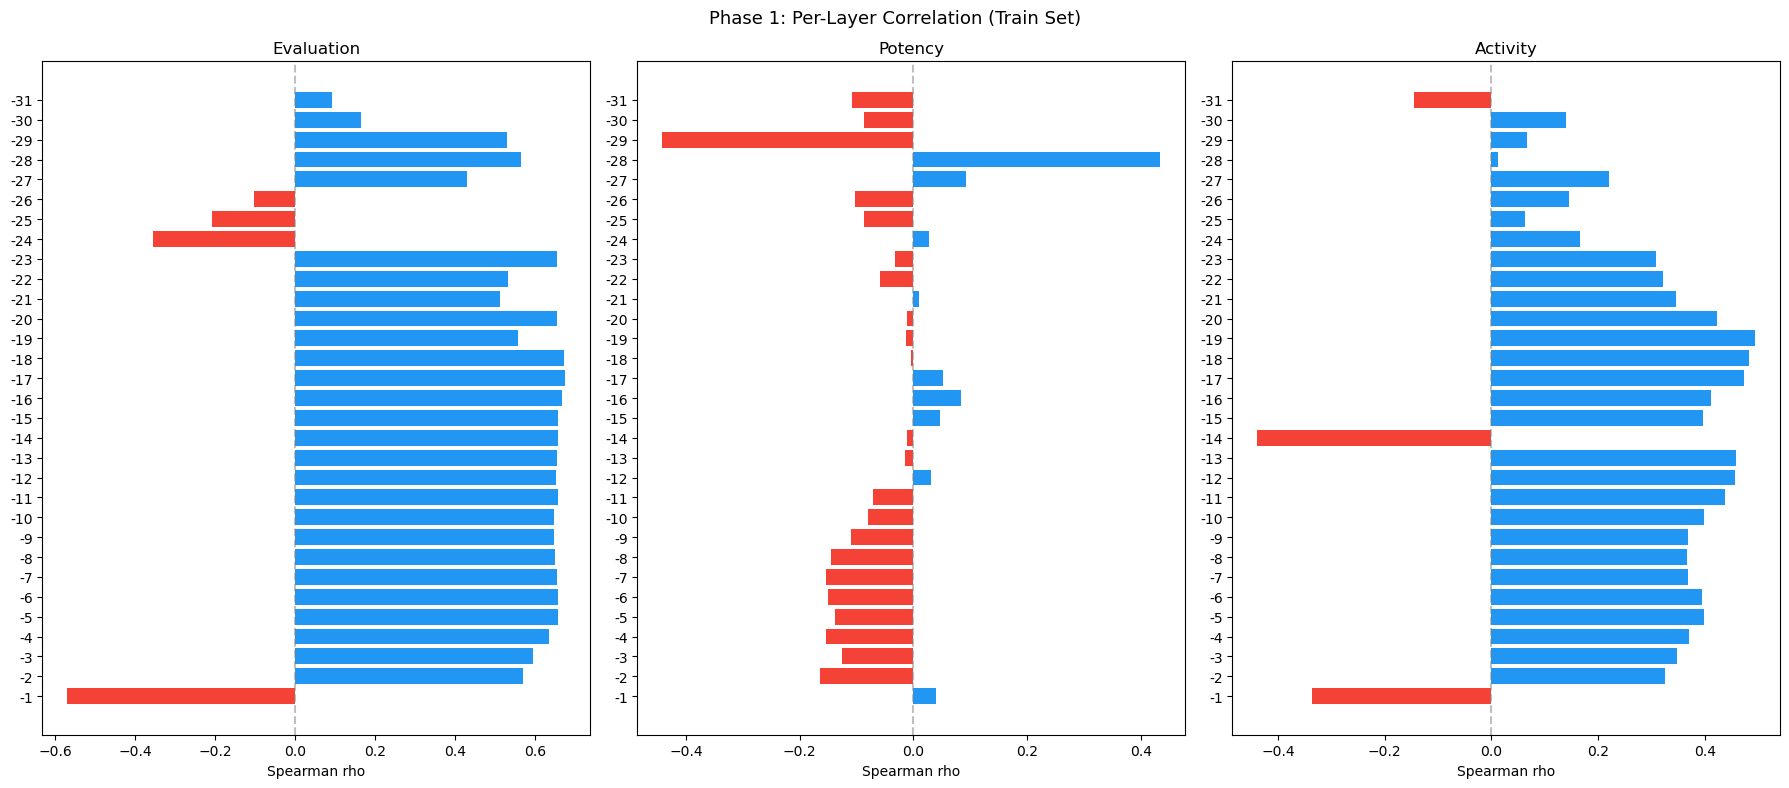

Saved reading_v2_phase1.png


In [5]:
# === Cell 5: Phase 1 — Individual Layer Correlation (on train) ===
phase1 = {dim: {} for dim in DIMENSIONS}
for dim in DIMENSIONS:
    for layer in all_layers:
        rho, pval = spearmanr(train_scores[dim][layer], train_gt[dim])
        phase1[dim][layer] = {"rho": float(rho), "pval": float(pval)}

print("Phase 1: Per-Layer Spearman rho (on train set)")
for dim in DIMENSIONS:
    ranked = sorted(phase1[dim].items(), key=lambda x: abs(x[1]['rho']), reverse=True)
    print(f"\n{dim.upper()} — Top 10:")
    for layer, info in ranked[:10]:
        sign = "+" if info['rho'] > 0 else "-"
        bar = "#" * int(abs(info['rho']) * 40)
        print(f"  Layer {layer:4d}: rho={info['rho']:+.3f} {bar}")

# Phase 1 visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for idx, dim in enumerate(DIMENSIONS):
    sorted_l = sorted(all_layers)
    rhos = [phase1[dim][l]['rho'] for l in sorted_l]
    colors = ['#2196F3' if r > 0 else '#F44336' for r in rhos]
    axes[idx].barh([str(l) for l in sorted_l], rhos, color=colors)
    axes[idx].set_xlabel("Spearman rho"); axes[idx].set_title(f"{dim.capitalize()}")
    axes[idx].axvline(0, color='gray', ls='--', alpha=0.5); axes[idx].invert_yaxis()
plt.suptitle("Phase 1: Per-Layer Correlation (Train Set)", fontsize=13)
plt.tight_layout(); plt.savefig("reading_v2_phase1.png", dpi=150, bbox_inches='tight')
plt.show(); print("Saved reading_v2_phase1.png")

In [6]:
# === Cell 6: Helper Functions ===

def compute_weighted_reading(selected_lw, dim, scores_dict):
    """Weighted average of sign-corrected layer readings."""
    n = len(list(scores_dict[dim].values())[0])
    total = np.zeros(n)
    total_weight = 0.0
    for layer, weight in selected_lw.items():
        sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
        total += weight * sign * scores_dict[dim][layer]
        total_weight += weight
    return total / total_weight if total_weight > 0 else total

def eval_rho(selected_lw, dim, scores_dict, gt_dict):
    """Compute Spearman rho for a layer+weight combo."""
    avg = compute_weighted_reading(selected_lw, dim, scores_dict)
    rho, _ = spearmanr(avg, gt_dict[dim])
    return float(rho)

TOP_K = 15
MAX_LAYERS = 10
MIN_IMPROVEMENT = 0.002
WEIGHT_CANDIDATES = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

print(f"Parameters: TOP_K={TOP_K}, MAX_LAYERS={MAX_LAYERS}, "
      f"MIN_IMPROVEMENT={MIN_IMPROVEMENT}, WEIGHTS={WEIGHT_CANDIDATES}")

Parameters: TOP_K=15, MAX_LAYERS=10, MIN_IMPROVEMENT=0.002, WEIGHTS=[0.25, 0.5, 0.75, 1.0, 1.5, 2.0]


In [7]:
# === Cell 7: Method 1 — Simple Independent (Top-K Uniform Average) ===

SIMPLE_K = 5  # use top-5 by default
simple_results = {}

print(f"Simple Independent: uniform average of top-{SIMPLE_K} layers\n")
for dim in DIMENSIONS:
    ranked = sorted(phase1[dim].items(), key=lambda x: abs(x[1]['rho']), reverse=True)[:SIMPLE_K]
    selected = {l: 1.0 for l, _ in ranked}
    rho_train = eval_rho(selected, dim, train_scores, train_gt)
    simple_results[dim] = {"selected": selected, "rho_train": rho_train}
    layers_str = ", ".join([str(l) for l in sorted(selected.keys())])
    print(f"  {dim:12s}: rho_train={rho_train:+.3f}, layers=[{layers_str}]")

Simple Independent: uniform average of top-5 layers

  evaluation  : rho_train=+0.682, layers=[-18, -17, -16, -14, -6]
  potency     : rho_train=+0.179, layers=[-29, -28, -7, -4, -2]
  activity    : rho_train=+0.484, layers=[-19, -18, -17, -13, -12]


In [8]:
# === Cell 8: Method 2 — Greedy Forward Selection ===

greedy_results = {}
for dim in DIMENSIONS:
    print(f"\n{'='*50}\nGreedy: {dim.upper()}\n{'='*50}")
    ranked = sorted(phase1[dim].items(), key=lambda x: abs(x[1]['rho']), reverse=True)[:TOP_K]
    candidates = [l for l, _ in ranked]

    best_layer = candidates[0]
    selected = {best_layer: 1.0}
    cur_rho = eval_rho(selected, dim, train_scores, train_gt)
    print(f"  Step 0: layer {best_layer} w=1.0 => rho={cur_rho:+.3f}")

    for step in range(1, MAX_LAYERS):
        remaining = [l for l in candidates if l not in selected]
        if not remaining: break
        best_score = cur_rho
        best_add = None
        for cand in remaining:
            for w in WEIGHT_CANDIDATES:
                trial = {**selected, cand: w}
                rho = eval_rho(trial, dim, train_scores, train_gt)
                if rho > best_score:
                    best_score = rho
                    best_add = (cand, w)
        if best_add is None or (best_score - cur_rho) < MIN_IMPROVEMENT:
            print(f"  Step {step}: no improvement >= {MIN_IMPROVEMENT}, stopping.")
            break
        selected[best_add[0]] = best_add[1]
        cur_rho = best_score
        print(f"  Step {step}: +layer {best_add[0]} w={best_add[1]} => rho={cur_rho:+.3f}")

    greedy_results[dim] = {"selected": dict(selected), "rho_train": cur_rho}
    print(f"  Final: {len(selected)} layers, rho_train={cur_rho:+.3f}")


Greedy: EVALUATION
  Step 0: layer -17 w=1.0 => rho=+0.674
  Step 1: +layer -23 w=1.5 => rho=+0.699
  Step 2: +layer -5 w=0.25 => rho=+0.705
  Step 3: +layer -20 w=1.0 => rho=+0.708
  Step 4: no improvement >= 0.002, stopping.
  Final: 4 layers, rho_train=+0.708

Greedy: POTENCY
  Step 0: layer -29 w=1.0 => rho=+0.442
  Step 1: +layer -28 w=0.5 => rho=+0.454
  Step 2: no improvement >= 0.002, stopping.
  Final: 2 layers, rho_train=+0.454

Greedy: ACTIVITY
  Step 0: layer -19 w=1.0 => rho=+0.494
  Step 1: +layer -17 w=0.25 => rho=+0.501
  Step 2: no improvement >= 0.002, stopping.
  Final: 2 layers, rho_train=+0.501


In [9]:
# === Cell 9: Method 3 — SFFS (Sequential Floating Forward Selection) ===
# Like greedy, but after adding a layer, we try removing each existing layer.
# If removal improves the score, we remove it. This allows backtracking.

sffs_results = {}
for dim in DIMENSIONS:
    print(f"\n{'='*50}\nSFFS: {dim.upper()}\n{'='*50}")
    ranked = sorted(phase1[dim].items(), key=lambda x: abs(x[1]['rho']), reverse=True)[:TOP_K]
    candidates = [l for l, _ in ranked]

    best_layer = candidates[0]
    selected = {best_layer: 1.0}
    cur_rho = eval_rho(selected, dim, train_scores, train_gt)
    print(f"  Init: layer {best_layer} w=1.0 => rho={cur_rho:+.3f}")

    for step in range(1, MAX_LAYERS):
        # --- Forward step: try adding a layer ---
        remaining = [l for l in candidates if l not in selected]
        if not remaining: break
        best_score = cur_rho
        best_add = None
        for cand in remaining:
            for w in WEIGHT_CANDIDATES:
                trial = {**selected, cand: w}
                rho = eval_rho(trial, dim, train_scores, train_gt)
                if rho > best_score:
                    best_score = rho
                    best_add = (cand, w)
        if best_add is None or (best_score - cur_rho) < MIN_IMPROVEMENT:
            print(f"  Step {step}: no forward improvement >= {MIN_IMPROVEMENT}, stopping.")
            break
        selected[best_add[0]] = best_add[1]
        cur_rho = best_score
        print(f"  Step {step} ADD: +layer {best_add[0]} w={best_add[1]} => rho={cur_rho:+.3f} ({len(selected)} layers)")

        # --- Backward step: try removing each layer (except if it would leave us empty) ---
        improved = True
        while improved and len(selected) > 1:
            improved = False
            best_remove = None
            best_remove_rho = cur_rho
            for layer_to_remove in list(selected.keys()):
                trial = {k: v for k, v in selected.items() if k != layer_to_remove}
                # Also try re-optimizing remaining weights
                rho = eval_rho(trial, dim, train_scores, train_gt)
                if rho > best_remove_rho:
                    best_remove_rho = rho
                    best_remove = layer_to_remove
            if best_remove is not None:
                del selected[best_remove]
                cur_rho = best_remove_rho
                improved = True
                print(f"         REM: -layer {best_remove} => rho={cur_rho:+.3f} ({len(selected)} layers)")

    sffs_results[dim] = {"selected": dict(selected), "rho_train": cur_rho}
    print(f"  Final: {len(selected)} layers, rho_train={cur_rho:+.3f}")
    for l, w in sorted(selected.items()):
        s = "+" if phase1[dim][l]['rho'] > 0 else "-"
        print(f"    Layer {l:4d}: w={w}, sign={s}, rho={phase1[dim][l]['rho']:+.3f}")


SFFS: EVALUATION
  Init: layer -17 w=1.0 => rho=+0.674
  Step 1 ADD: +layer -23 w=1.5 => rho=+0.699 (2 layers)
  Step 2 ADD: +layer -5 w=0.25 => rho=+0.705 (3 layers)
  Step 3 ADD: +layer -20 w=1.0 => rho=+0.708 (4 layers)
  Step 4: no forward improvement >= 0.002, stopping.
  Final: 4 layers, rho_train=+0.708
    Layer  -23: w=1.5, sign=+, rho=+0.654
    Layer  -20: w=1.0, sign=+, rho=+0.653
    Layer  -17: w=1.0, sign=+, rho=+0.674
    Layer   -5: w=0.25, sign=+, rho=+0.656

SFFS: POTENCY
  Init: layer -29 w=1.0 => rho=+0.442
  Step 1 ADD: +layer -28 w=0.5 => rho=+0.454 (2 layers)
  Step 2: no forward improvement >= 0.002, stopping.
  Final: 2 layers, rho_train=+0.454
    Layer  -29: w=1.0, sign=-, rho=-0.442
    Layer  -28: w=0.5, sign=+, rho=+0.434

SFFS: ACTIVITY
  Init: layer -19 w=1.0 => rho=+0.494
  Step 1 ADD: +layer -17 w=0.25 => rho=+0.501 (2 layers)
  Step 2: no forward improvement >= 0.002, stopping.
  Final: 2 layers, rho_train=+0.501
    Layer  -19: w=1.0, sign=+, rho=+

In [10]:
# === Cell 10: Methods 4 & 5 — Ridge (Non-Negative) & ElasticNet (Non-Negative) ===

def build_feature_matrix(dim, scores_dict):
    """Build sign-corrected feature matrix (n_samples x n_layers)."""
    n = len(list(scores_dict[dim].values())[0])
    X = np.zeros((n, len(all_layers)))
    for j, layer in enumerate(all_layers):
        sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
        X[:, j] = sign * scores_dict[dim][layer]
    return X

ridge_results = {}
enet_results = {}

for dim in DIMENSIONS:
    X_train = build_feature_matrix(dim, train_scores)
    y_train = train_gt[dim]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    # --- Non-negative Ridge (ElasticNet with l1_ratio~0) ---
    ridge = ElasticNetCV(
        l1_ratio=[0.01], alphas=np.logspace(-4, 4, 50),
        cv=5, positive=True, max_iter=10000)
    ridge.fit(X_scaled, y_train)
    ridge_pred = ridge.predict(X_scaled)
    ridge_rho, _ = spearmanr(ridge_pred, y_train)
    ridge_weights = ridge.coef_ / scaler.scale_
    n_active_r = int(np.sum(ridge_weights > 1e-6))

    # Store as {layer: weight} dict for active layers
    ridge_selected = {}
    for j, layer in enumerate(all_layers):
        if ridge_weights[j] > 1e-6:
            ridge_selected[layer] = float(round(ridge_weights[j], 6))

    ridge_results[dim] = {
        'model': ridge, 'scaler': scaler, 'selected': ridge_selected,
        'weights_orig': ridge_weights, 'rho_train': float(ridge_rho),
        'n_active': n_active_r, 'alpha': float(ridge.alpha_),
    }
    print(f"RIDGE  {dim.upper():12s}: rho_train={ridge_rho:+.3f}, "
          f"active={n_active_r}/{len(all_layers)}, alpha={ridge.alpha_:.4f}")

    # --- Non-negative ElasticNet ---
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], alphas=np.logspace(-4, 2, 50),
        cv=5, positive=True, max_iter=10000)
    enet.fit(X_scaled, y_train)
    enet_pred = enet.predict(X_scaled)
    enet_rho, _ = spearmanr(enet_pred, y_train)
    enet_weights = enet.coef_ / scaler.scale_
    n_active_e = int(np.sum(enet_weights > 1e-6))

    enet_selected = {}
    for j, layer in enumerate(all_layers):
        if enet_weights[j] > 1e-6:
            enet_selected[layer] = float(round(enet_weights[j], 6))

    enet_results[dim] = {
        'model': enet, 'scaler': scaler, 'selected': enet_selected,
        'weights_orig': enet_weights, 'rho_train': float(enet_rho),
        'n_active': n_active_e, 'alpha': float(enet.alpha_),
        'l1_ratio': float(enet.l1_ratio_),
    }
    print(f"ENET   {dim.upper():12s}: rho_train={enet_rho:+.3f}, "
          f"active={n_active_e}/{len(all_layers)}, "
          f"alpha={enet.alpha_:.4f}, l1={enet.l1_ratio_:.1f}")
    print()

RIDGE  EVALUATION  : rho_train=+0.727, active=11/31, alpha=0.0409
ENET   EVALUATION  : rho_train=+0.726, active=10/31, alpha=0.0022, l1=0.1

RIDGE  POTENCY     : rho_train=+0.482, active=22/31, alpha=0.3907
ENET   POTENCY     : rho_train=+0.491, active=12/31, alpha=0.1151, l1=0.1

RIDGE  ACTIVITY    : rho_train=+0.516, active=12/31, alpha=0.3907
ENET   ACTIVITY    : rho_train=+0.517, active=8/31, alpha=0.1526, l1=0.1



In [11]:
# === Cell 11: Linear Regression Calibration (Train) + Test Evaluation ===
# For each method, fit a simple affine transform on train: raw_reading -> EPA scale.
# Then evaluate on the test set.

ALL_METHODS = {
    'Simple': simple_results,
    'Greedy': greedy_results,
    'SFFS': sffs_results,
    'Ridge': ridge_results,
    'ElasticNet': enet_results,
}

calibrations = {}  # method -> dim -> {slope, intercept, metrics_train, metrics_test}

for method_name, results in ALL_METHODS.items():
    calibrations[method_name] = {}
    for dim in DIMENSIONS:
        sel = results[dim]['selected']
        
        # Raw readings (weighted avg of sign-corrected layers)
        train_raw = compute_weighted_reading(sel, dim, train_scores)
        test_raw = compute_weighted_reading(sel, dim, test_scores)
        
        # Fit linear calibration on train
        lr = LinearRegression()
        lr.fit(train_raw.reshape(-1, 1), train_gt[dim])
        
        # Calibrated predictions
        train_cal = lr.predict(train_raw.reshape(-1, 1))
        test_cal = lr.predict(test_raw.reshape(-1, 1))
        
        # Metrics
        def compute_metrics(pred, gt):
            rho, _ = spearmanr(pred, gt)
            pear, _ = pearsonr(pred, gt)
            mae = mean_absolute_error(gt, pred)
            rmse = np.sqrt(mean_squared_error(gt, pred))
            r2 = r2_score(gt, pred)
            return {'spearman': float(rho), 'pearson': float(pear),
                    'mae': float(mae), 'rmse': float(rmse), 'r2': float(r2)}
        
        m_train = compute_metrics(train_cal, train_gt[dim])
        m_test = compute_metrics(test_cal, test_gt[dim])
        
        calibrations[method_name][dim] = {
            'slope': float(lr.coef_[0]),
            'intercept': float(lr.intercept_),
            'lr': lr,
            'train_cal': train_cal,
            'test_cal': test_cal,
            'train_raw': train_raw,
            'test_raw': test_raw,
            'metrics_train': m_train,
            'metrics_test': m_test,
        }

# --- Print comparison table ---
print("\n" + "="*90)
print("TEST SET RESULTS (calibrated)")
print("="*90)
header = f"{'Method':<12s}  {'Dim':<12s}  {'rho':>6s}  {'pearson':>8s}  {'MAE':>6s}  {'RMSE':>6s}  {'R2':>6s}  {'#Lyr':>5s}"
print(header); print("-" * len(header))
for method_name in ALL_METHODS:
    for dim in DIMENSIONS:
        m = calibrations[method_name][dim]['metrics_test']
        n_layers = len(ALL_METHODS[method_name][dim]['selected'])
        print(f"{method_name:<12s}  {dim:<12s}  {m['spearman']:+.3f}  {m['pearson']:+6.3f}  "
              f"{m['mae']:.3f}  {m['rmse']:.3f}  {m['r2']:+.3f}  {n_layers:5d}")
    print()


TEST SET RESULTS (calibrated)
Method        Dim              rho   pearson     MAE    RMSE      R2   #Lyr
---------------------------------------------------------------------------
Simple        evaluation    +0.711  +0.749  1.008  1.214  +0.549      5
Simple        potency       +0.401  +0.445  0.667  0.755  +0.181      5
Simple        activity      +0.581  +0.612  0.485  0.602  +0.362      5

Greedy        evaluation    +0.720  +0.757  0.988  1.191  +0.566      4
Greedy        potency       +0.441  +0.489  0.638  0.733  +0.229      2
Greedy        activity      +0.553  +0.599  0.482  0.608  +0.349      2

SFFS          evaluation    +0.720  +0.757  0.988  1.191  +0.566      4
SFFS          potency       +0.441  +0.489  0.638  0.733  +0.229      2
SFFS          activity      +0.553  +0.599  0.482  0.608  +0.349      2

Ridge         evaluation    +0.731  +0.785  0.924  1.127  +0.612     11
Ridge         potency       +0.565  +0.639  0.580  0.665  +0.366     22
Ridge         activity

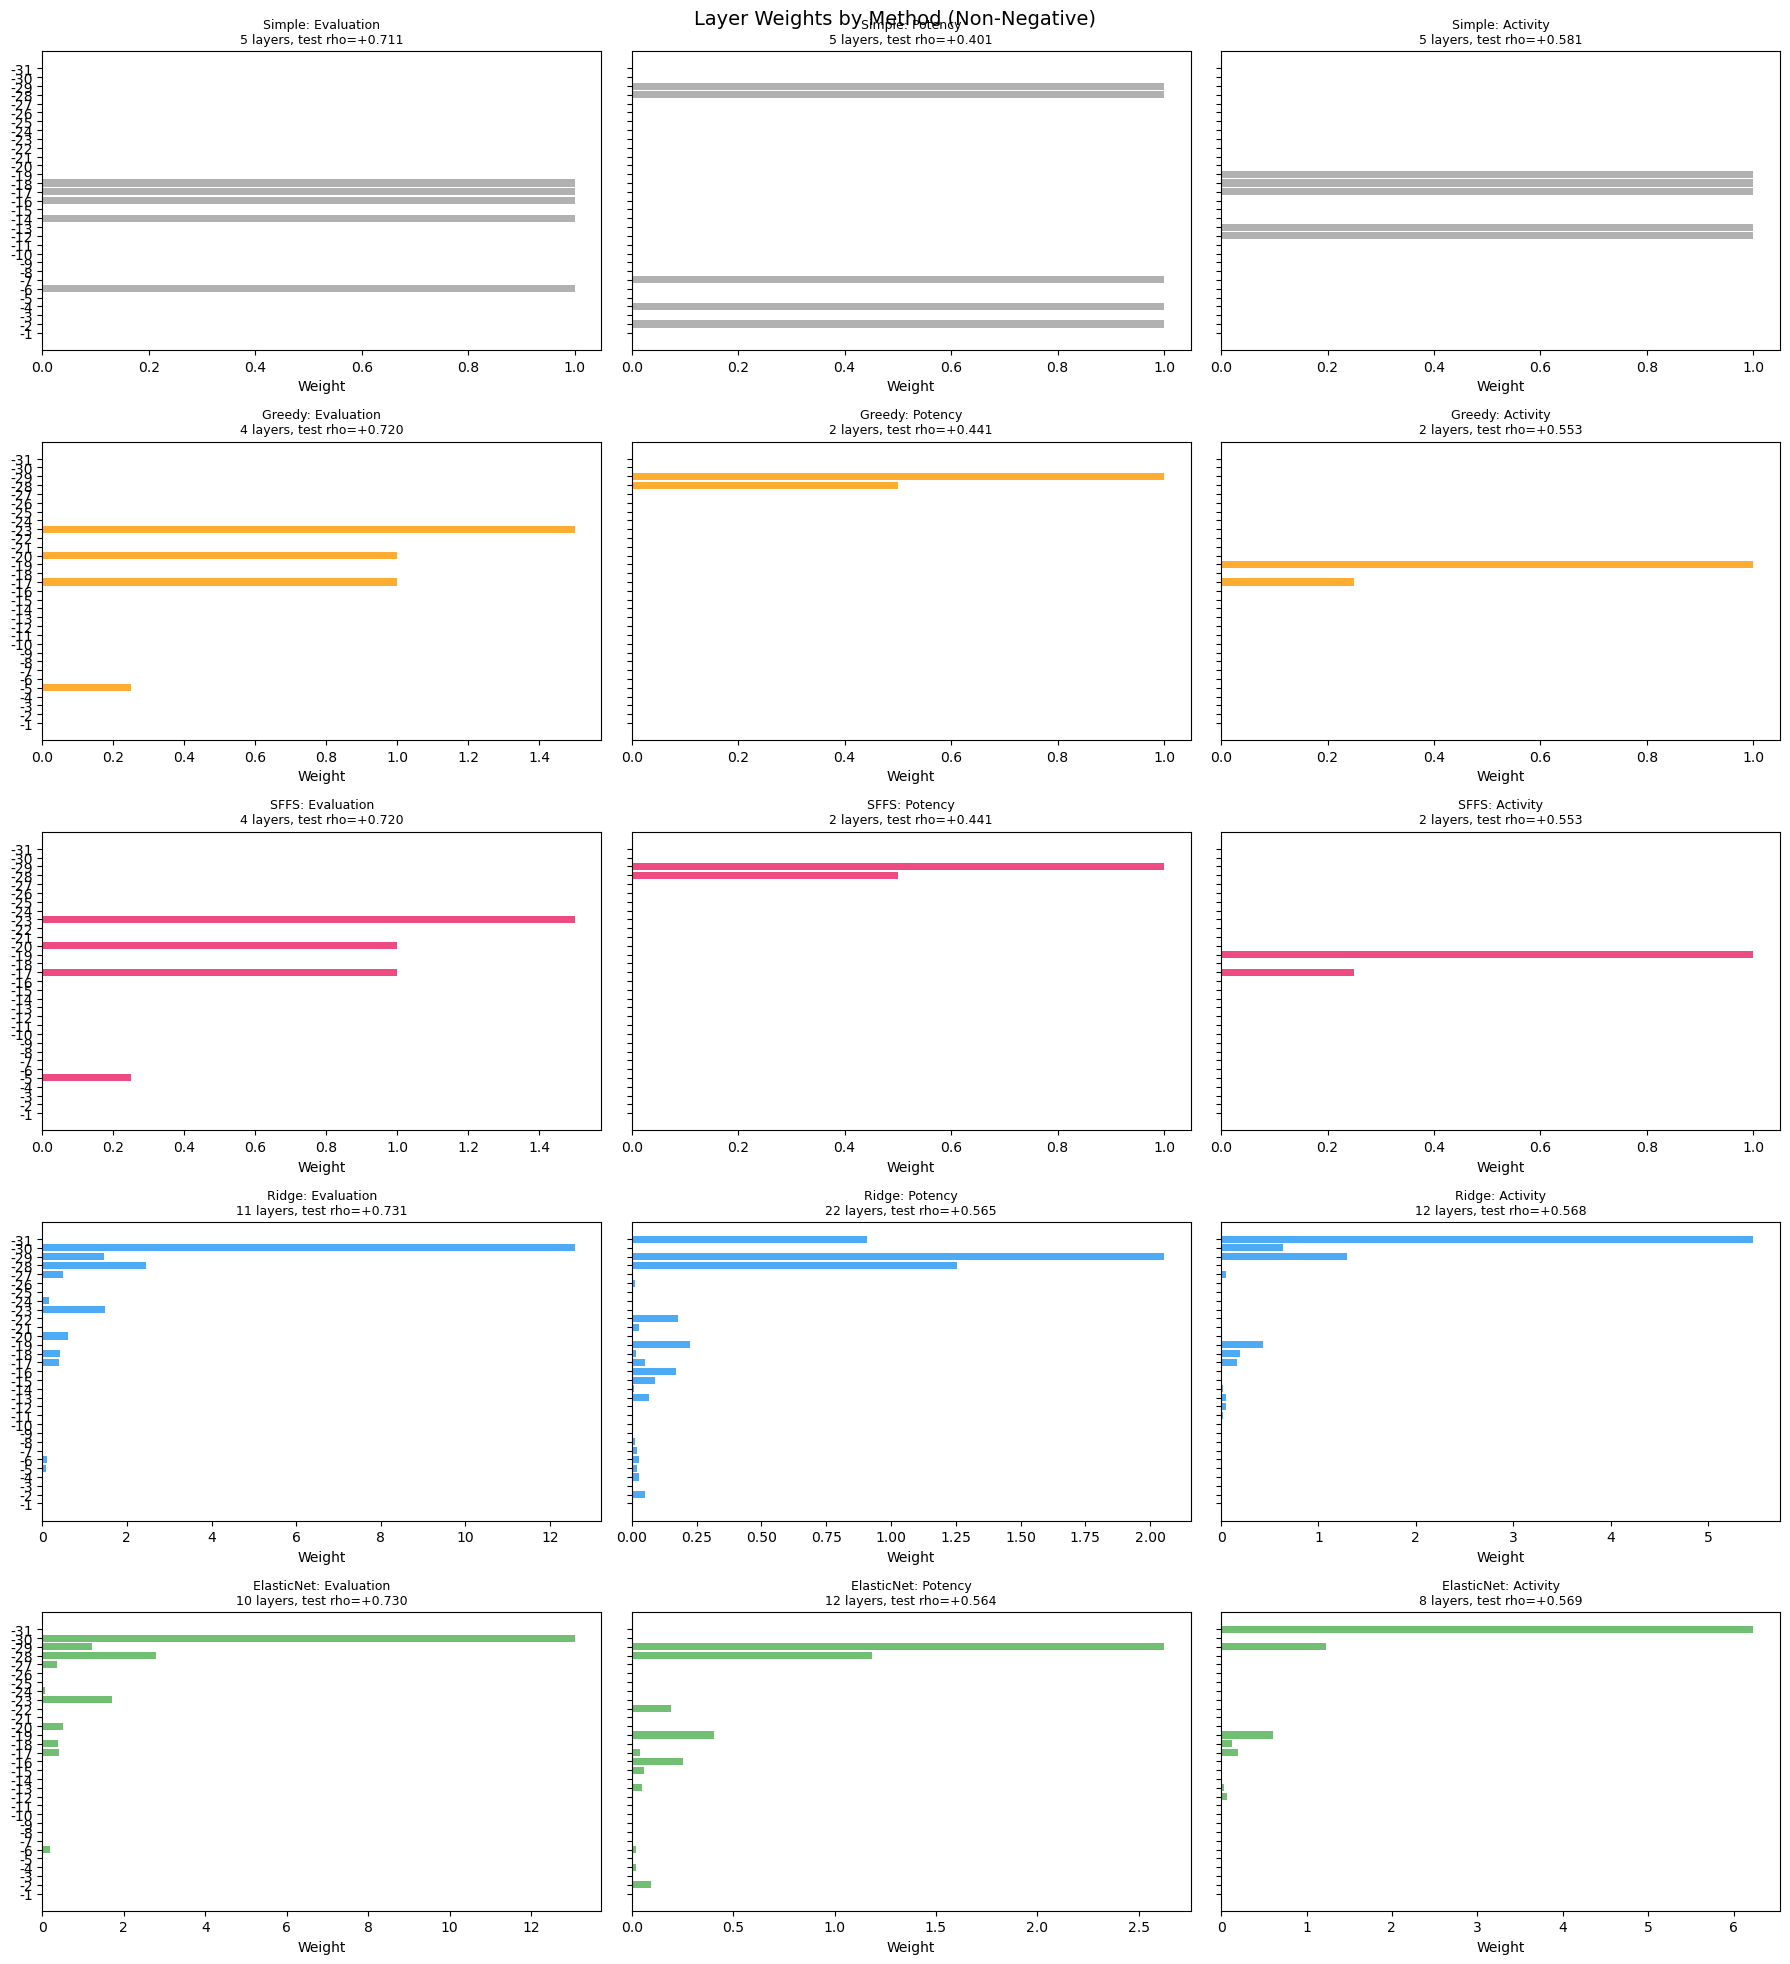

Saved reading_v2_weights.png


In [12]:
# === Cell 12: Visualization — Weight Profiles ===

method_colors = {'Simple': '#9E9E9E', 'Greedy': '#FF9800', 'SFFS': '#E91E63',
                 'Ridge': '#2196F3', 'ElasticNet': '#4CAF50'}
method_list = list(ALL_METHODS.keys())

fig, axes = plt.subplots(len(method_list), 3, figsize=(18, 4 * len(method_list)))
for row, method_name in enumerate(method_list):
    for col, dim in enumerate(DIMENSIONS):
        sel = ALL_METHODS[method_name][dim]['selected']
        sorted_layers = sorted(all_layers)
        weights = [sel.get(l, 0.0) for l in sorted_layers]
        color = method_colors[method_name]
        axes[row, col].barh([str(l) for l in sorted_layers], weights, color=color, alpha=0.8)
        axes[row, col].set_xlabel("Weight")
        rho_test = calibrations[method_name][dim]['metrics_test']['spearman']
        n = len(sel)
        axes[row, col].set_title(f"{method_name}: {dim.capitalize()}\n"
                                 f"{n} layers, test rho={rho_test:+.3f}", fontsize=9)
        axes[row, col].invert_yaxis()
        if col > 0: axes[row, col].set_yticklabels([])

plt.suptitle("Layer Weights by Method (Non-Negative)", fontsize=14)
plt.tight_layout()
plt.savefig("reading_v2_weights.png", dpi=150, bbox_inches='tight'); plt.show()
print("Saved reading_v2_weights.png")

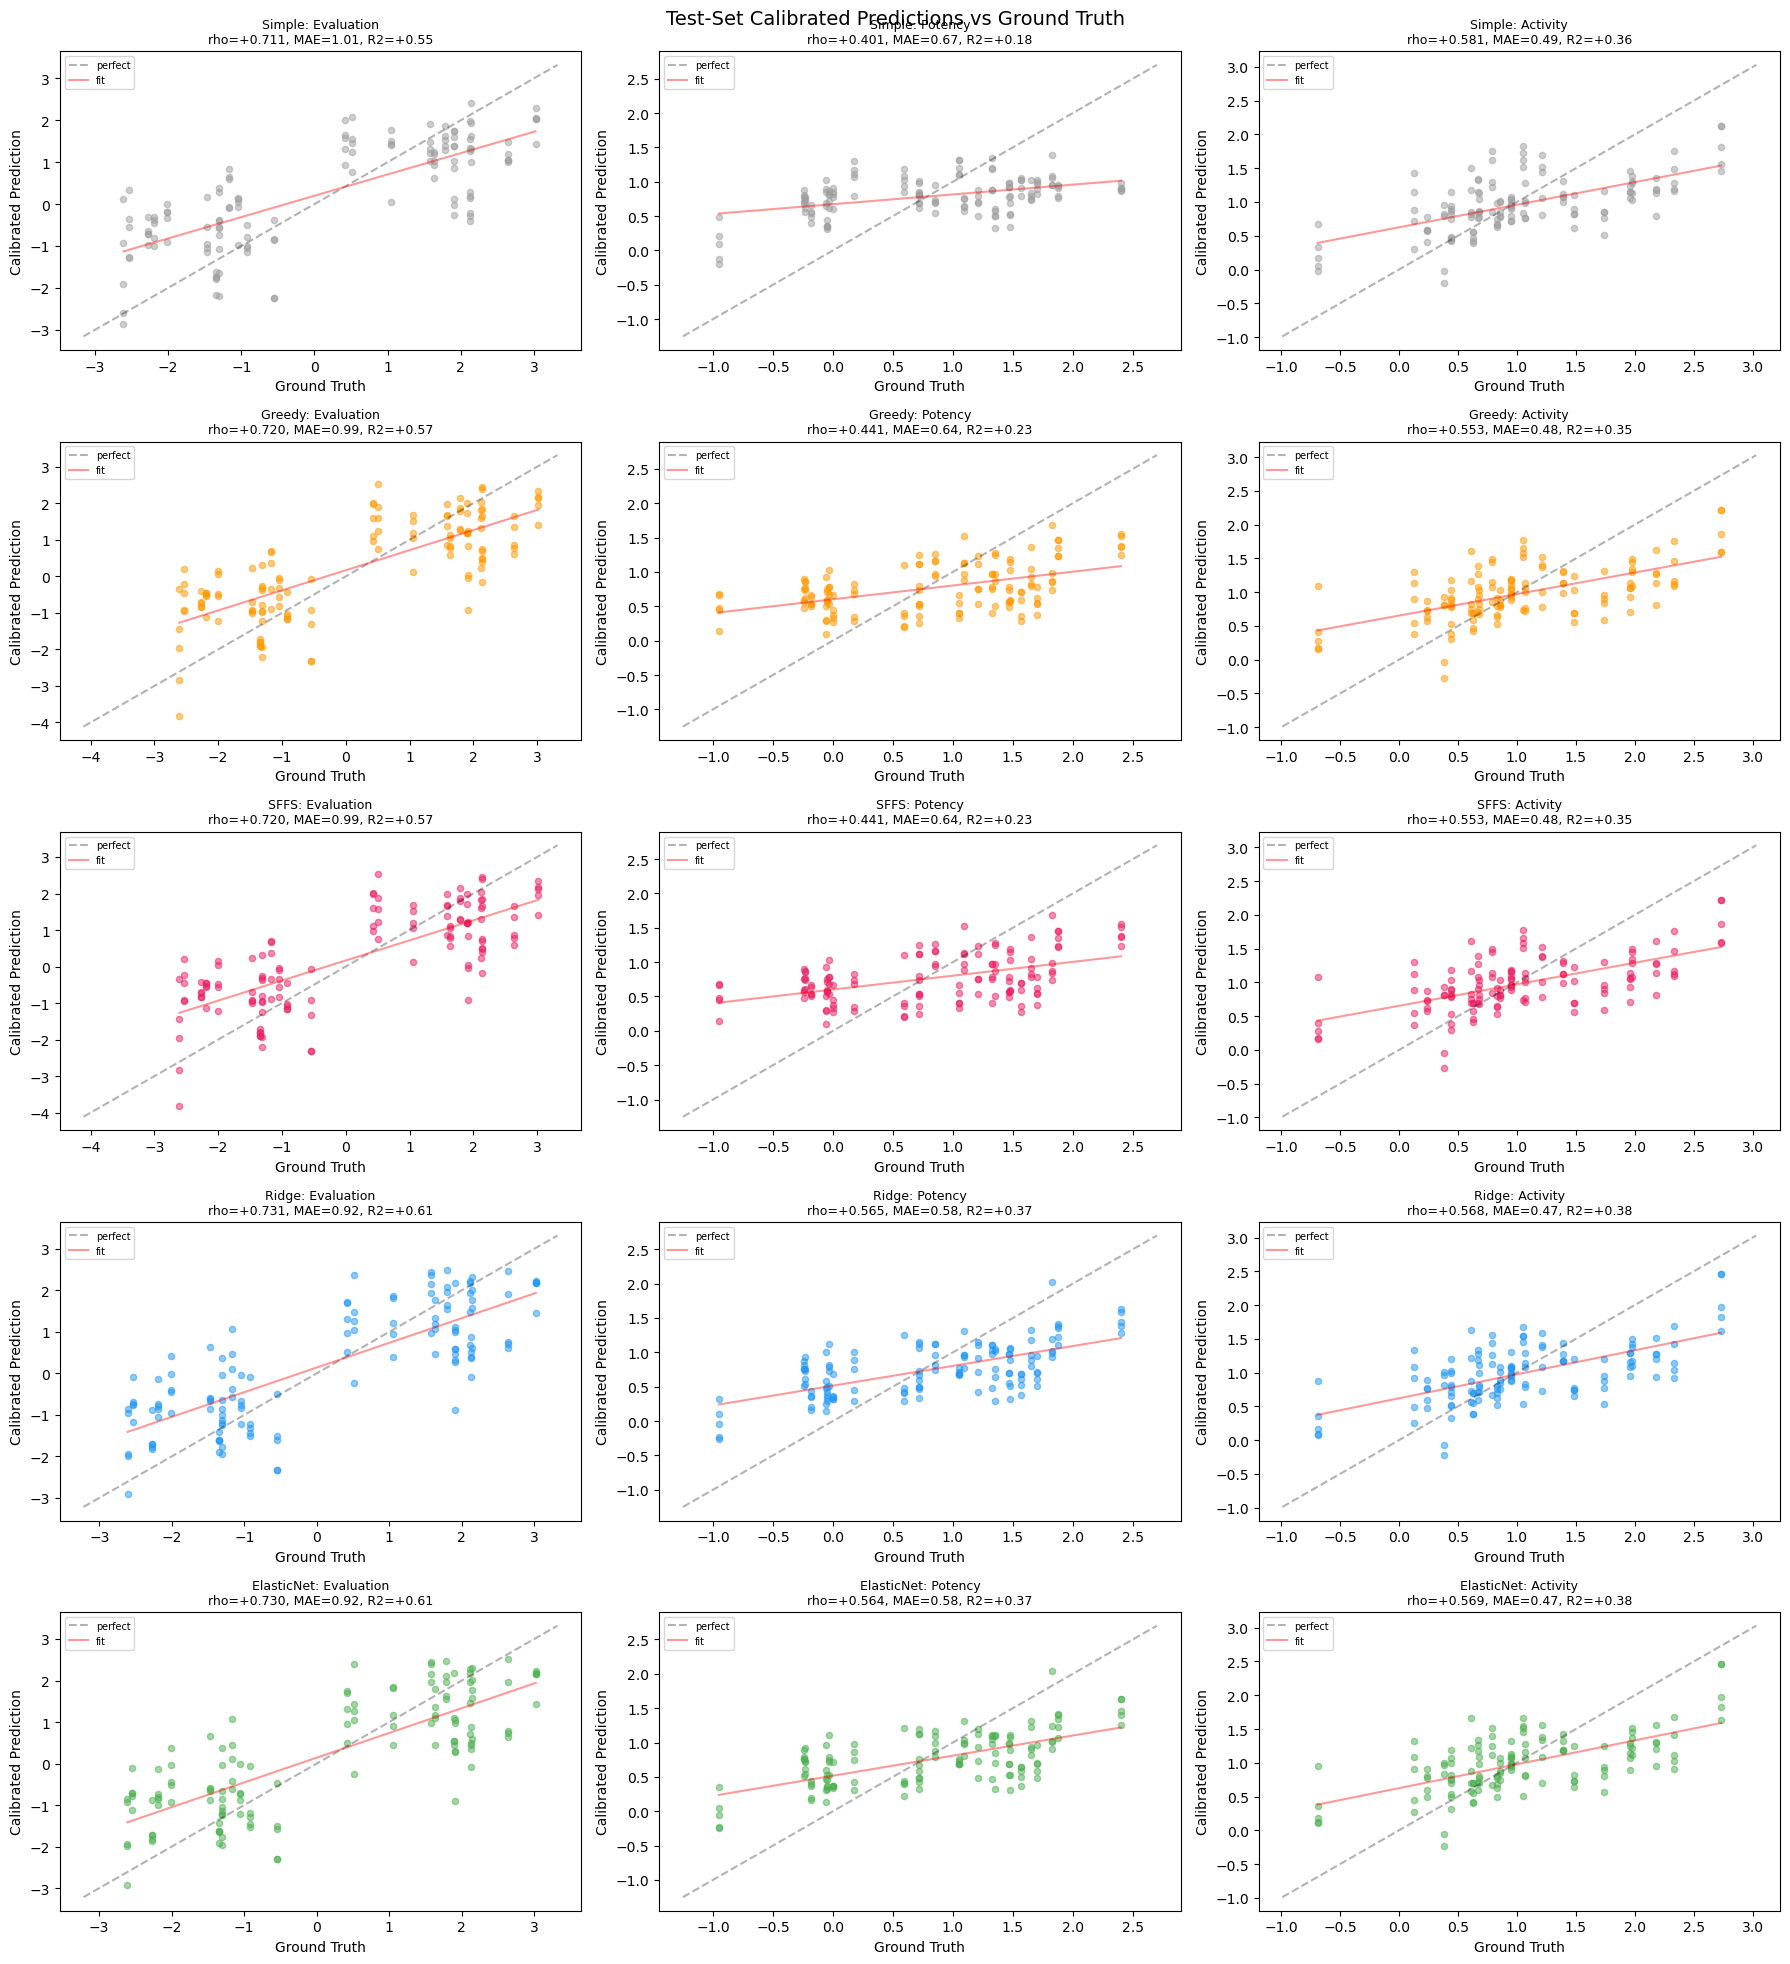

Saved reading_v2_scatter.png


In [13]:
# === Cell 13: Visualization — Test-Set Scatter Plots (calibrated) ===

fig, axes = plt.subplots(len(method_list), 3, figsize=(18, 4 * len(method_list)))
for row, method_name in enumerate(method_list):
    for col, dim in enumerate(DIMENSIONS):
        pred = calibrations[method_name][dim]['test_cal']
        gt = test_gt[dim]
        m = calibrations[method_name][dim]['metrics_test']

        axes[row, col].scatter(gt, pred, alpha=0.5, s=20, c=method_colors[method_name])
        lims = [min(gt.min(), pred.min()) - 0.3, max(gt.max(), pred.max()) + 0.3]
        axes[row, col].plot(lims, lims, 'k--', alpha=0.3, label='perfect')
        z = np.polyfit(gt, pred, 1)
        x_line = np.linspace(gt.min(), gt.max(), 100)
        axes[row, col].plot(x_line, np.polyval(z, x_line), 'r-', alpha=0.4, label='fit')
        axes[row, col].set_xlabel("Ground Truth"); axes[row, col].set_ylabel("Calibrated Prediction")
        axes[row, col].set_title(f"{method_name}: {dim.capitalize()}\n"
                                 f"rho={m['spearman']:+.3f}, MAE={m['mae']:.2f}, R2={m['r2']:+.2f}", fontsize=9)
        axes[row, col].legend(fontsize=7)

plt.suptitle("Test-Set Calibrated Predictions vs Ground Truth", fontsize=14)
plt.tight_layout()
plt.savefig("reading_v2_scatter.png", dpi=150, bbox_inches='tight'); plt.show()
print("Saved reading_v2_scatter.png")

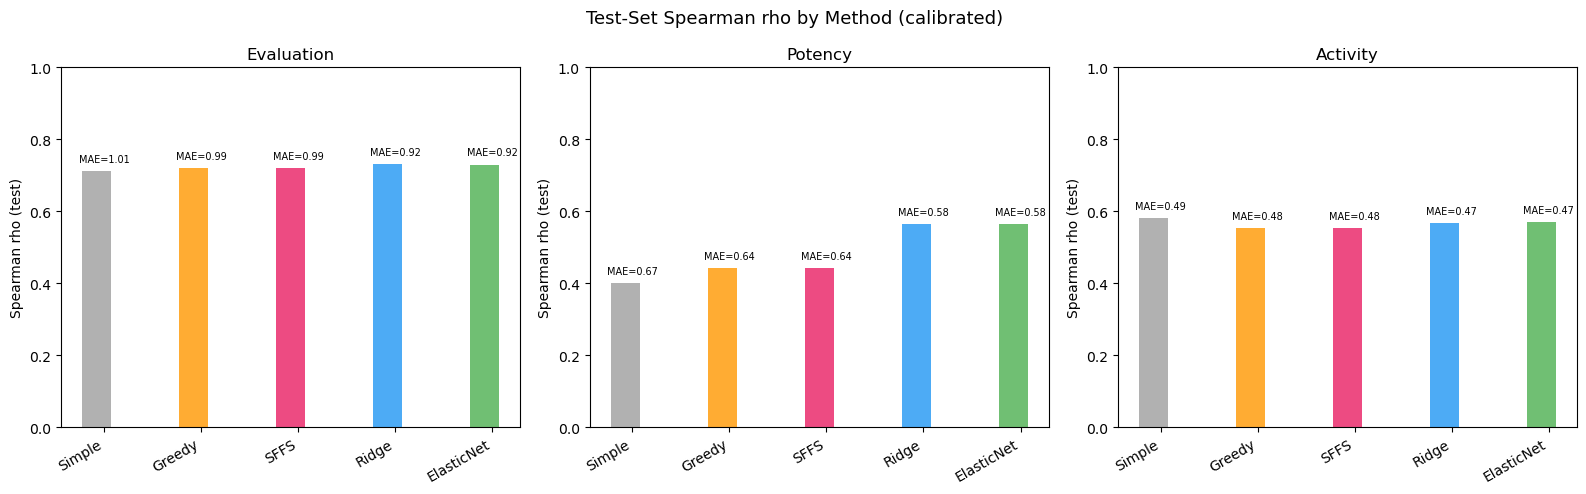

Saved reading_v2_comparison.png


In [14]:
# === Cell 14: Visualization — Method Comparison Bar Charts ===

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_width = 0.15
x = np.arange(len(method_list))

for col, dim in enumerate(DIMENSIONS):
    train_rhos = [calibrations[m][dim]['metrics_train']['spearman'] for m in method_list]
    test_rhos = [calibrations[m][dim]['metrics_test']['spearman'] for m in method_list]
    test_maes = [calibrations[m][dim]['metrics_test']['mae'] for m in method_list]

    colors = [method_colors[m] for m in method_list]
    axes[col].bar(x - bar_width/2, test_rhos, bar_width * 2, color=colors, alpha=0.8)
    axes[col].set_xticks(x); axes[col].set_xticklabels(method_list, rotation=30, ha='right')
    axes[col].set_ylabel("Spearman rho (test)")
    axes[col].set_title(f"{dim.capitalize()}")
    axes[col].set_ylim(0, 1)

    # Annotate with MAE
    for i, (rho, mae) in enumerate(zip(test_rhos, test_maes)):
        axes[col].text(i, rho + 0.02, f'MAE={mae:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle("Test-Set Spearman rho by Method (calibrated)", fontsize=13)
plt.tight_layout()
plt.savefig("reading_v2_comparison.png", dpi=150, bbox_inches='tight'); plt.show()
print("Saved reading_v2_comparison.png")

In [15]:
# === Cell 15: Compare 5 Random Test Examples ===

random.seed(42)
example_indices = sorted(random.sample(range(len(test_utterances)), 5))

print("=" * 110)
print("COMPARISON ON 5 RANDOM TEST EXAMPLES (calibrated predictions)")
print("=" * 110)

for i, idx in enumerate(example_indices):
    u = test_utterances[idx]
    gt_e = u['target_epa']['e']
    gt_p = u['target_epa']['p']
    gt_a = u['target_epa']['a']

    print(f"\n--- Example {i+1} (test idx={idx}, behavior='{u['behavior']}') ---")
    print(f"Text: {u['text'][:120]}{'...' if len(u['text']) > 120 else ''}")
    print(f"{'Ground Truth':20s}   E={gt_e:+6.2f}   P={gt_p:+6.2f}   A={gt_a:+6.2f}")

    for method_name in ALL_METHODS:
        ce = calibrations[method_name]['evaluation']['test_cal'][idx]
        cp = calibrations[method_name]['potency']['test_cal'][idx]
        ca = calibrations[method_name]['activity']['test_cal'][idx]
        err = np.sqrt((ce - gt_e)**2 + (cp - gt_p)**2 + (ca - gt_a)**2)
        print(f"{method_name:20s}   E={ce:+6.2f}   P={cp:+6.2f}   A={ca:+6.2f}   "
              f"err: {abs(ce-gt_e):.2f}/{abs(cp-gt_p):.2f}/{abs(ca-gt_a):.2f}  L2={err:.2f}")

COMPARISON ON 5 RANDOM TEST EXAMPLES (calibrated predictions)

--- Example 1 (test idx=6, behavior='counsel') ---
Text: Hey, I think it's really brave of you to take a step back and acknowledge your emotions, that's a huge first step toward...
Ground Truth           E= +2.14   P= +1.65   A= +0.24
Simple                 E= +2.42   P= +0.83   A= +0.57   err: 0.28/0.82/0.33  L2=0.93
Greedy                 E= +2.44   P= +1.37   A= +0.63   err: 0.30/0.28/0.39  L2=0.57
SFFS                   E= +2.44   P= +1.37   A= +0.63   err: 0.30/0.28/0.39  L2=0.57
Ridge                  E= +2.32   P= +1.32   A= +0.59   err: 0.18/0.33/0.35  L2=0.52
ElasticNet             E= +2.29   P= +1.31   A= +0.59   err: 0.15/0.34/0.35  L2=0.52

--- Example 2 (test idx=28, behavior='greet') ---
Text: Hey, how's it going?
Ground Truth           E= +2.64   P= +1.35   A= +1.05
Simple                 E= +1.00   P= +0.32   A= +0.84   err: 1.64/1.03/0.21  L2=1.95
Greedy                 E= +0.85   P= +0.50   A= +0.73   err:

In [16]:
# === Cell 16: Save Results ===

output = {
    "metadata": {
        "model_name": model_name,
        "tuned_at": datetime.now().isoformat(),
        "train_path": TRAIN_PATH,
        "test_path": TEST_PATH,
        "n_train": len(train_utterances),
        "n_test": len(test_utterances),
        "n_layers": len(all_layers),
        "method": "representation_reading_v2",
        "note": "5 methods compared. Calibrated with linear regression. Test metrics are honest.",
    },
    "phase1_correlations": {},
    "methods": {},
}

for dim in DIMENSIONS:
    output["phase1_correlations"][dim] = {
        str(l): phase1[dim][l] for l in sorted(phase1[dim].keys())
    }

for method_name, results in ALL_METHODS.items():
    output["methods"][method_name] = {}
    for dim in DIMENSIONS:
        sel = results[dim]['selected']
        cal = calibrations[method_name][dim]
        output["methods"][method_name][dim] = {
            "selected_layers": {str(k): v for k, v in sel.items()},
            "layer_signs": {
                str(l): ("+" if phase1[dim][l]['rho'] > 0 else "-")
                for l in sel
            },
            "n_layers": len(sel),
            "rho_train": results[dim]['rho_train'],
            "calibration": {
                "slope": cal['slope'],
                "intercept": cal['intercept'],
            },
            "metrics_train": cal['metrics_train'],
            "metrics_test": cal['metrics_test'],
        }

RESULTS_PATH = "epa_reading_tuning_v2_results.json"
with open(RESULTS_PATH, 'w') as f:
    json.dump(output, f, indent=2)
print(f"Results saved to {RESULTS_PATH}")

# --- Summary ---
print("\n" + "="*70)
print("FINAL SUMMARY (Test Set, Calibrated)")
print("="*70)
for method_name in ALL_METHODS:
    print(f"\n{method_name}:")
    for dim in DIMENSIONS:
        o = output['methods'][method_name][dim]
        mt = o['metrics_test']
        print(f"  {dim:12s}: {o['n_layers']:2d} layers, "
              f"test rho={mt['spearman']:+.3f}, MAE={mt['mae']:.3f}, R2={mt['r2']:+.3f}")

Results saved to epa_reading_tuning_v2_results.json

FINAL SUMMARY (Test Set, Calibrated)

Simple:
  evaluation  :  5 layers, test rho=+0.711, MAE=1.008, R2=+0.549
  potency     :  5 layers, test rho=+0.401, MAE=0.667, R2=+0.181
  activity    :  5 layers, test rho=+0.581, MAE=0.485, R2=+0.362

Greedy:
  evaluation  :  4 layers, test rho=+0.720, MAE=0.988, R2=+0.566
  potency     :  2 layers, test rho=+0.441, MAE=0.638, R2=+0.229
  activity    :  2 layers, test rho=+0.553, MAE=0.482, R2=+0.349

SFFS:
  evaluation  :  4 layers, test rho=+0.720, MAE=0.988, R2=+0.566
  potency     :  2 layers, test rho=+0.441, MAE=0.638, R2=+0.229
  activity    :  2 layers, test rho=+0.553, MAE=0.482, R2=+0.349

Ridge:
  evaluation  : 11 layers, test rho=+0.731, MAE=0.924, R2=+0.612
  potency     : 22 layers, test rho=+0.565, MAE=0.580, R2=+0.366
  activity    : 12 layers, test rho=+0.568, MAE=0.471, R2=+0.383

ElasticNet:
  evaluation  : 10 layers, test rho=+0.730, MAE=0.924, R2=+0.612
  potency     : 12 

In [ ]:
# Load epa_reading_tuning_v2_results.json



In [17]:
# === Steering Setup: Derive initial coefficients from reading tuning ===
# Step 1: Use reading-tuned layers and signs
# Step 2: Start with uniform base coefficient, let calibration handle scale

# Create the control pipeline (for steering)
# RepControlPipeline requires layers at init time — use all_layers
from repe.rep_control_pipeline import RepControlPipeline
rep_control_pipeline = RepControlPipeline(
    model=model, tokenizer=tokenizer, layers=all_layers,
    block_name="decoder_block", control_method="reading_vec",
)

# Choose which reading method to base steering on (best test-set performer)
READING_METHOD = "ElasticNet"  # change to "Ridge", "SFFS", "Greedy", "Simple"

# Base steering magnitude (will be tuned)
BASE_COEFF = 2.0

# Build steering configs from reading results
steering_configs = {}  # dim -> {layers, signs, base_coeff, calibration}

for dim in DIMENSIONS:
    method_data = ALL_METHODS[READING_METHOD][dim]
    cal = calibrations[READING_METHOD][dim]
    selected = method_data['selected']
    
    # Extract layers and their reading signs
    layers = sorted(selected.keys())
    signs = {}
    for layer in layers:
        reading_sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
        signs[layer] = reading_sign
    
    steering_configs[dim] = {
        'layers': layers,
        'signs': signs,
        'weights': {l: selected[l] for l in layers},
        'base_coeff': BASE_COEFF,
        'calibration_slope': cal['slope'],
        'calibration_intercept': cal['intercept'],
        'lr': cal['lr'],
    }
    
    print(f"\n{dim.upper()} steering config:")
    print(f"  Layers: {layers}")
    print(f"  Calibration: EPA = {cal['slope']:.4f} * raw_reading + {cal['intercept']:.4f}")
    for l in layers:
        s = "+" if signs[l] > 0 else "-"
        w = selected[l]
        print(f"    Layer {l:4d}: reading_sign={s}, reading_weight={w:.4f}")


Device set to use cuda:0



EVALUATION steering config:
  Layers: [-30, -29, -28, -27, -24, -23, -20, -18, -17, -6]
  Calibration: EPA = 20.7447 * raw_reading + -1.1342
    Layer  -30: reading_sign=+, reading_weight=13.0668
    Layer  -29: reading_sign=+, reading_weight=1.2290
    Layer  -28: reading_sign=+, reading_weight=2.7859
    Layer  -27: reading_sign=+, reading_weight=0.3688
    Layer  -24: reading_sign=-, reading_weight=0.0659
    Layer  -23: reading_sign=+, reading_weight=1.7092
    Layer  -20: reading_sign=+, reading_weight=0.5063
    Layer  -18: reading_sign=+, reading_weight=0.3863
    Layer  -17: reading_sign=+, reading_weight=0.4114
    Layer   -6: reading_sign=+, reading_weight=0.1994

POTENCY steering config:
  Layers: [-29, -28, -22, -19, -17, -16, -15, -13, -6, -4, -2, -1]
  Calibration: EPA = 5.5993 * raw_reading + 1.2027
    Layer  -29: reading_sign=-, reading_weight=2.6246
    Layer  -28: reading_sign=+, reading_weight=1.1833
    Layer  -22: reading_sign=-, reading_weight=0.1919
    Layer  

In [18]:
# === Steering + Reading Evaluation Functions ===

def build_activations(dim, target_epa, coeff_override=None):
    """
    Build activations dict for steering toward a target EPA value.
    Each value must be a TENSOR (scaled direction vector), not a scalar.
    """
    config = steering_configs[dim]
    reader = rep_readers[dim]
    activations = {}
    
    for layer in all_layers:
        if layer in config['layers']:
            if coeff_override and layer in coeff_override:
                coeff = coeff_override[layer]
            else:
                coeff = config['base_coeff']
            sign = config['signs'][layer] * np.sign(target_epa)
            # Activation = coeff * sign * direction_sign * direction_vector (tensor)
            direction = torch.tensor(reader.directions[layer], dtype=torch.float16)
            dir_sign = float(reader.direction_signs[layer])
            activations[layer] = coeff * sign * dir_sign * direction
        else:
            # Zero vector — no steering at this layer
            direction = torch.tensor(reader.directions[layer], dtype=torch.float16)
            activations[layer] = torch.zeros_like(direction)
    
    return activations


def steer_and_generate(prompt, dim, target_epa, coeff_override=None, max_new_tokens=128):
    """Generate text with representation steering applied."""
    activations = build_activations(dim, target_epa, coeff_override)
    
    outputs = rep_control_pipeline(
        prompt,
        activations=activations,
        batch_size=1,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        repetition_penalty=1.2,
    )
    
    generated = outputs[0]['generated_text']
    if generated.startswith(prompt):
        generated = generated[len(prompt):]
    
    return generated.strip(), activations



def read_and_calibrate(text, method=READING_METHOD):
    """Read EPA from text using the calibrated reading pipeline."""
    formatted = format_for_reading(text)
    
    epa_readings = {}
    for dim in DIMENSIONS:
        config = steering_configs[dim]
        sel = ALL_METHODS[method][dim]['selected']
        
        reader = rep_readers[dim]
        scores = rep_reading_pipeline(
            [formatted], hidden_layers=all_layers, rep_reader=reader,
            batch_size=1, padding=True, truncation=True,
        )
        
        total = 0.0
        total_weight = 0.0
        for layer, weight in sel.items():
            sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
            raw = float(scores[0][layer])
            total += weight * sign * raw
            total_weight += weight
        raw_reading = total / total_weight if total_weight > 0 else 0.0
        
        cal_epa = config['lr'].predict([[raw_reading]])[0]
        epa_readings[dim] = {'raw': raw_reading, 'calibrated': cal_epa}
    
    return epa_readings

print("Steering and evaluation functions ready.")
print(f"Base coefficient: {BASE_COEFF}")
print(f"Reading method: {READING_METHOD}")


Steering and evaluation functions ready.
Base coefficient: 2.0
Reading method: ElasticNet


In [19]:
# === Step 3 & 4: Steer + Read to Evaluate ===

test_idx = 0
example = test_utterances[test_idx]
gt_epa = example['target_epa']

print(f"Behavior: '{example['behavior']}'")
print(f"Target EPA: E={gt_epa['e']:+.2f}, P={gt_epa['p']:+.2f}, A={gt_epa['a']:+.2f}")
print()

system = None
user_msg = "Pretend you're a person making a statement in a conversation."
prompt = format_for_reading("", neutral_context=user_msg)

# --- Baseline: generate WITHOUT steering ---
print("=" * 80)
print("BASELINE (no steering)")
print("=" * 80)
baseline_out = rep_control_pipeline(
    prompt, activations=None,
    batch_size=1, max_new_tokens=128, do_sample=False, repetition_penalty=1.2,
)[0]['generated_text']

if baseline_out.startswith(prompt):
    baseline_out = baseline_out[len(prompt):]
baseline_out = baseline_out.strip()
print(f"Generated: {baseline_out[:200]}")
baseline_epa = read_and_calibrate(baseline_out)
print(f"Read EPA: E={baseline_epa['evaluation']['calibrated']:+.2f}, "
      f"P={baseline_epa['potency']['calibrated']:+.2f}, "
      f"A={baseline_epa['activity']['calibrated']:+.2f}")

# --- Steered: apply steering for each dimension independently ---
print()
for dim in DIMENSIONS:
    dim_key = DIM_KEY[dim]
    target = gt_epa[dim_key]
    
    print("=" * 80)
    print(f"STEERED: {dim.upper()} toward {target:+.2f}")
    print("=" * 80)
    
    steered_text, activations = steer_and_generate(prompt, dim, target)
    print(f"Generated: {steered_text[:200]}")
    
    steered_epa = read_and_calibrate(steered_text)
    print(f"Read EPA:  E={steered_epa['evaluation']['calibrated']:+.2f}, "
          f"P={steered_epa['potency']['calibrated']:+.2f}, "
          f"A={steered_epa['activity']['calibrated']:+.2f}")
    print(f"Target:    {dim}={target:+.2f}")
    print(f"Delta:     {steered_epa[dim]['calibrated'] - baseline_epa[dim]['calibrated']:+.2f} "
          f"(baseline={baseline_epa[dim]['calibrated']:+.2f})")
    print()


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Behavior: 'invite'
Target EPA: E=+2.13, P=+1.48, A=+0.61

BASELINE (no steering)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generated: I'm really excited to be trying out this new restaurant downtown that just opened up last week, I've heard amazing things about their brunch menu and the atmosphere is supposed to be super trendy. Hav
Read EPA: E=+0.30, P=+1.22, A=+0.87

STEERED: EVALUATION toward +2.13


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generated: ##There are many things that can be said about kindness and compassion, especially when it comes to the importance of empathy**

In our daily lives we often find ourselves getting caught up in cycles 
Read EPA:  E=+0.28, P=+1.27, A=+0.79
Target:    evaluation=+2.13
Delta:     -0.02 (baseline=+0.30)

STEERED: POTENCY toward +1.48


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generated: I think the new policy is going to be implemented, but I'm not sure if it's actually effective yet.
Read EPA:  E=+0.74, P=+1.13, A=+0.37
Target:    potency=+1.48
Delta:     -0.09 (baseline=+1.22)

STEERED: ACTIVITY toward +0.61
Generated: I just told my friend, "Honey, darling! I've got the scoop on me! and I'm here to tell ya!, Get ready for it! Get outta, get hot, get crazy, get set, get the dish! - what are we? What's next?! We have
Read EPA:  E=-3.16, P=+0.44, A=+2.13
Target:    activity=+0.61
Delta:     +1.26 (baseline=+0.87)



In [29]:
# === Coefficient Sweep: Find the best base magnitude ===
# For each dimension, try different base coefficients and measure 
# how well the calibrated reading matches the target EPA.

COEFF_CANDIDATES = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]
N_SWEEP_EXAMPLES = 5  # how many test examples to evaluate

random.seed(42)
sweep_indices = sorted(random.sample(range(len(test_utterances)), N_SWEEP_EXAMPLES))

sweep_results = {dim: {} for dim in DIMENSIONS}

for dim in DIMENSIONS:
    dim_key = DIM_KEY[dim]
    print(f"\n{'='*60}")
    print(f"SWEEPING: {dim.upper()}")
    print(f"{'='*60}")
    
    for coeff in COEFF_CANDIDATES:
        errors = []
        deltas = []
        
        for idx in sweep_indices:
            target = test_utterances[idx]['target_epa'][dim_key]
            
            # Override all layers with this coefficient
            override = {l: coeff for l in steering_configs[dim]['layers']}
            steered_text, _ = steer_and_generate(prompt, dim, target, coeff_override=override)
            steered_epa = read_and_calibrate(steered_text)
            
            calibrated = steered_epa[dim]['calibrated']
            error = abs(calibrated - target)
            errors.append(error)
            deltas.append(calibrated - target)
        
        mean_err = np.mean(errors)
        mean_delta = np.mean(deltas)
        sweep_results[dim][coeff] = {
            'mean_abs_error': float(mean_err),
            'mean_delta': float(mean_delta),
            'errors': errors,
        }
        print(f"  coeff={coeff:.1f}: mean_abs_error={mean_err:.3f}, mean_delta={mean_delta:+.3f}")
    
    # Find best coefficient
    best_coeff = min(sweep_results[dim], key=lambda c: sweep_results[dim][c]['mean_abs_error'])
    print(f"  => Best coeff: {best_coeff:.1f} (MAE={sweep_results[dim][best_coeff]['mean_abs_error']:.3f})")


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



SWEEPING: EVALUATION


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  coeff=0.5: mean_abs_error=2.752, mean_delta=-2.752


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

  coeff=3.0: mean_abs_error=0.880, mean_delta=+0.880


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  coeff=4.0: mean_abs_error=0.249, mean_delta=+0.204


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  coeff=5.0: mean_abs_error=0.225, mean_delta=+0.017
  => Best coeff: 5.0 (MAE=0.225)


In [20]:
# === Steering Hyperparameter Search: All Reading Methods × Coefficient Magnitudes ===
# For each reading method, derive steering layers/signs, sweep coefficients,
# and measure how well steering moves the calibrated reading toward the target.

COEFF_CANDIDATES = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0]
N_SWEEP_EXAMPLES = 10
random.seed(42)
sweep_indices = sorted(random.sample(range(len(test_utterances)), N_SWEEP_EXAMPLES))

# Neutral prompt for generation
prompt = format_for_reading("", neutral_context="Pretend you're a person making a statement in a conversation.")

# Store all sweep results: method -> dim -> coeff -> metrics
all_sweep_results = {}

for method_name in ALL_METHODS:
    print(f"\n{'#'*70}")
    print(f"# READING METHOD: {method_name}")
    print(f"{'#'*70}")
    
    # Rebuild steering_configs for this reading method
    for dim in DIMENSIONS:
        method_data = ALL_METHODS[method_name][dim]
        cal = calibrations[method_name][dim]
        selected = method_data['selected']
        layers = sorted(selected.keys())
        signs = {}
        for layer in layers:
            reading_sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
            signs[layer] = reading_sign
        steering_configs[dim] = {
            'layers': layers,
            'signs': signs,
            'weights': {l: selected[l] for l in layers},
            'base_coeff': BASE_COEFF,
            'calibration_slope': cal['slope'],
            'calibration_intercept': cal['intercept'],
            'lr': cal['lr'],
        }
    
    all_sweep_results[method_name] = {}
    
    for dim in DIMENSIONS:
        dim_key = DIM_KEY[dim]
        all_sweep_results[method_name][dim] = {}
        
        for coeff in COEFF_CANDIDATES:
            errors = []
            signed_errors = []
            target_vals = []
            read_vals = []
            
            for idx in sweep_indices:
                target = test_utterances[idx]['target_epa'][dim_key]
                override = {l: coeff for l in steering_configs[dim]['layers']}
                
                try:
                    steered_text, _ = steer_and_generate(prompt, dim, target, coeff_override=override)
                    steered_epa = read_and_calibrate(steered_text, method=method_name)
                    calibrated = steered_epa[dim]['calibrated']
                except Exception as e:
                    calibrated = 0.0  # fallback
                
                errors.append(abs(calibrated - target))
                signed_errors.append(calibrated - target)
                target_vals.append(target)
                read_vals.append(calibrated)
            
            rho, _ = spearmanr(target_vals, read_vals) if len(set(target_vals)) > 1 else (0.0, 1.0)
            
            result = {
                'mae': float(np.mean(errors)),
                'mean_signed_error': float(np.mean(signed_errors)),
                'spearman': float(rho),
                'targets': target_vals,
                'reads': read_vals,
            }
            all_sweep_results[method_name][dim][coeff] = result
            print(f"  {method_name:12s} {dim:12s} coeff={coeff:4.1f}: "
                  f"MAE={result['mae']:.3f}, bias={result['mean_signed_error']:+.3f}, rho={rho:+.3f}")
        
        # Best coeff for this method+dim
        best_c = min(all_sweep_results[method_name][dim],
                     key=lambda c: all_sweep_results[method_name][dim][c]['mae'])
        best = all_sweep_results[method_name][dim][best_c]
        print(f"  >>> BEST: coeff={best_c:.1f}, MAE={best['mae']:.3f}, rho={best['spearman']:+.3f}")
        print()

print("\nSweep complete!")


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



######################################################################
# READING METHOD: Simple
######################################################################


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

  Simple       evaluation   coeff= 0.5: MAE=1.432, bias=-1.120, rho=+0.701


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

...

  ElasticNet   activity     coeff= 3.0: MAE=0.876, bias=+0.876, rho=+nan


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

  ElasticNet   activity     coeff= 5.0: MAE=0.302, bias=+0.013, rho=+nan


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

  ElasticNet   activity     coeff= 8.0: MAE=0.316, bias=+0.115, rho=+nan
  >>> BEST: coeff=5.0, MAE=0.302, rho=+nan


Sweep complete!


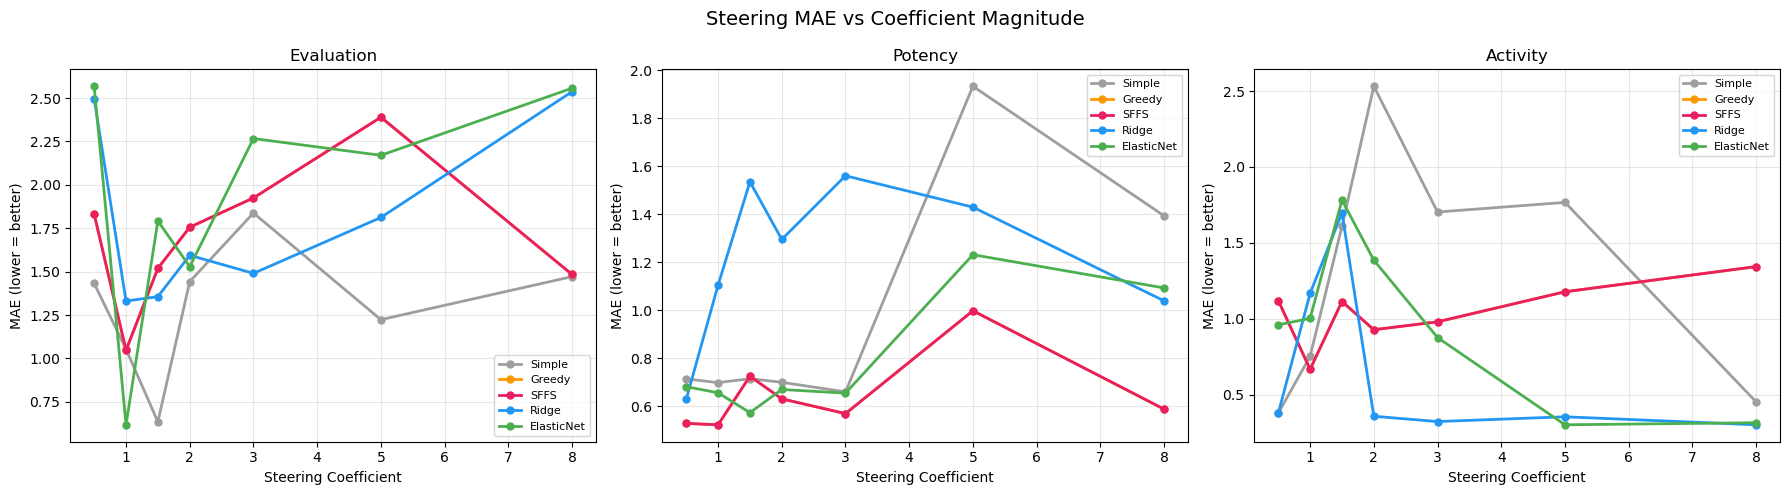

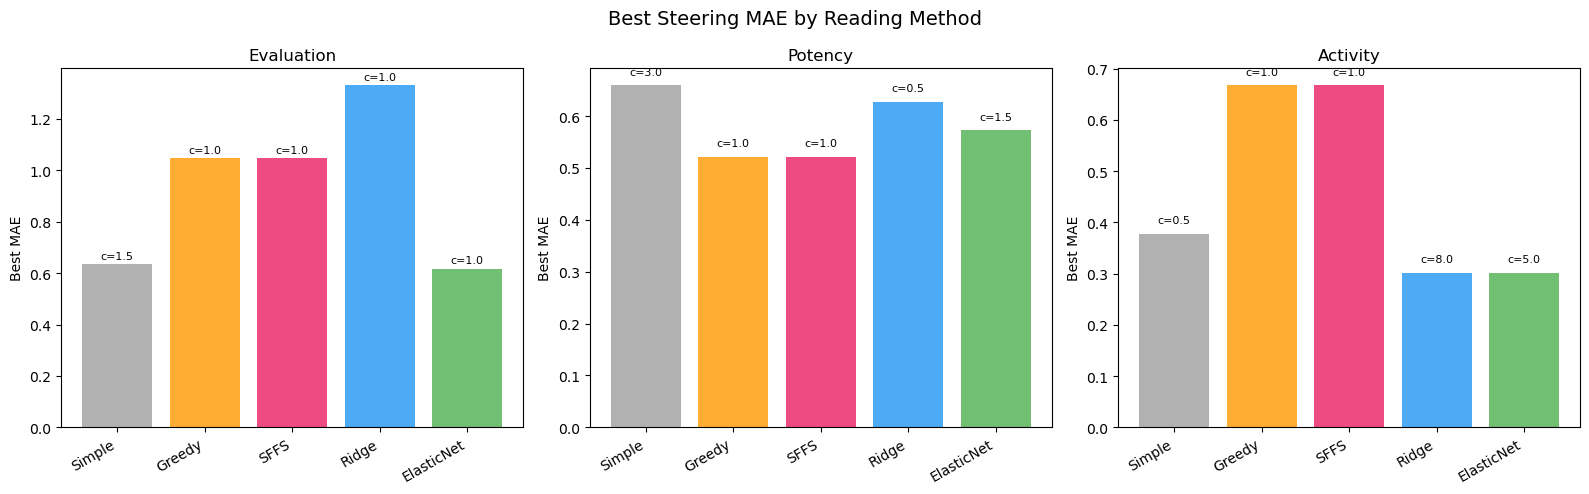

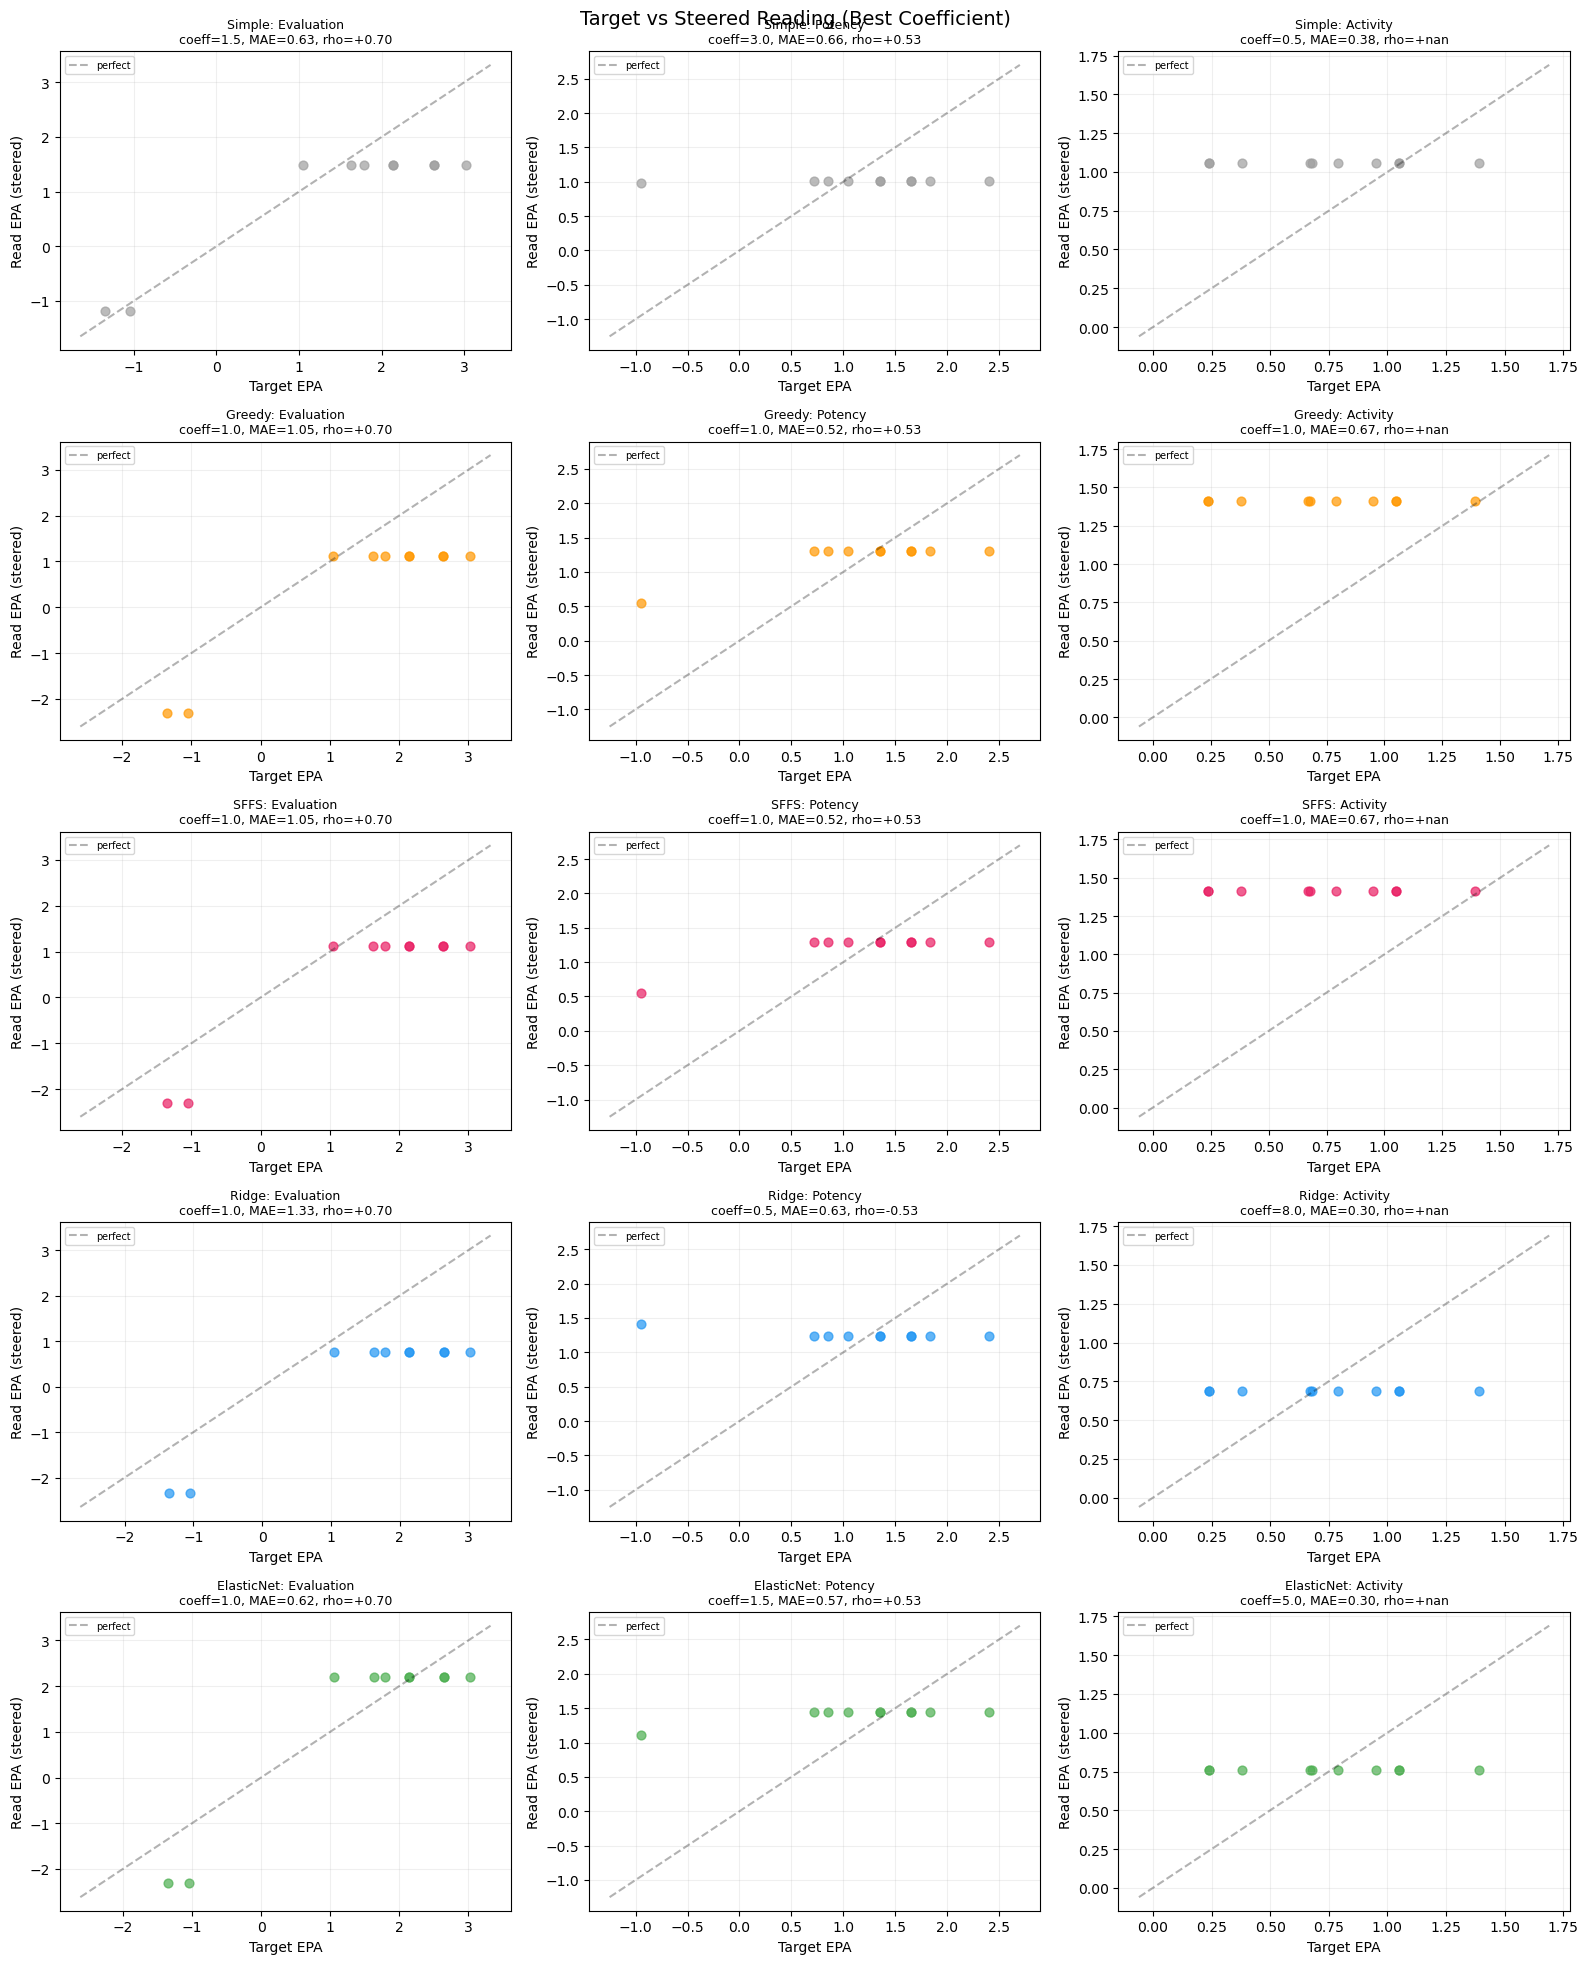

Saved: steering_mae_vs_coeff.png, steering_best_mae.png, steering_target_vs_read.png


In [21]:
# === Visualization: Steering Effectiveness Across Methods ===

method_names = list(ALL_METHODS.keys())
method_colors = {'Simple': '#9E9E9E', 'Greedy': '#FF9800', 'SFFS': '#E91E63',
                 'Ridge': '#2196F3', 'ElasticNet': '#4CAF50'}

# --- Plot 1: MAE vs Coefficient for each method×dim ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for col, dim in enumerate(DIMENSIONS):
    for method_name in method_names:
        coeffs = sorted(all_sweep_results[method_name][dim].keys())
        maes = [all_sweep_results[method_name][dim][c]['mae'] for c in coeffs]
        axes[col].plot(coeffs, maes, 'o-', label=method_name, 
                       color=method_colors[method_name], linewidth=2, markersize=5)
    axes[col].set_xlabel("Steering Coefficient")
    axes[col].set_ylabel("MAE (lower = better)")
    axes[col].set_title(f"{dim.capitalize()}")
    axes[col].legend(fontsize=8)
    axes[col].grid(True, alpha=0.3)
plt.suptitle("Steering MAE vs Coefficient Magnitude", fontsize=14)
plt.tight_layout()
plt.savefig("steering_mae_vs_coeff.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Best MAE per method (bar chart) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for col, dim in enumerate(DIMENSIONS):
    best_maes = []
    best_coeffs = []
    colors = []
    for method_name in method_names:
        best_c = min(all_sweep_results[method_name][dim],
                     key=lambda c: all_sweep_results[method_name][dim][c]['mae'])
        best_maes.append(all_sweep_results[method_name][dim][best_c]['mae'])
        best_coeffs.append(best_c)
        colors.append(method_colors[method_name])
    
    bars = axes[col].bar(range(len(method_names)), best_maes, color=colors, alpha=0.8)
    axes[col].set_xticks(range(len(method_names)))
    axes[col].set_xticklabels(method_names, rotation=30, ha='right')
    axes[col].set_ylabel("Best MAE")
    axes[col].set_title(f"{dim.capitalize()}")
    for i, (mae, c) in enumerate(zip(best_maes, best_coeffs)):
        axes[col].text(i, mae + 0.02, f'c={c:.1f}', ha='center', fontsize=8)
plt.suptitle("Best Steering MAE by Reading Method", fontsize=14)
plt.tight_layout()
plt.savefig("steering_best_mae.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 3: Target vs Read scatter for best coeff (per method×dim) ---
fig, axes = plt.subplots(len(method_names), 3, figsize=(16, 4 * len(method_names)))
for row, method_name in enumerate(method_names):
    for col, dim in enumerate(DIMENSIONS):
        best_c = min(all_sweep_results[method_name][dim],
                     key=lambda c: all_sweep_results[method_name][dim][c]['mae'])
        data = all_sweep_results[method_name][dim][best_c]
        targets = data['targets']
        reads = data['reads']
        
        axes[row, col].scatter(targets, reads, c=method_colors[method_name], alpha=0.7, s=40)
        lims = [min(min(targets), min(reads)) - 0.3, max(max(targets), max(reads)) + 0.3]
        axes[row, col].plot(lims, lims, 'k--', alpha=0.3, label='perfect')
        axes[row, col].set_xlabel("Target EPA")
        axes[row, col].set_ylabel("Read EPA (steered)")
        axes[row, col].set_title(f"{method_name}: {dim.capitalize()}\n"
                                  f"coeff={best_c:.1f}, MAE={data['mae']:.2f}, "
                                  f"rho={data['spearman']:+.2f}", fontsize=9)
        axes[row, col].legend(fontsize=7)
        axes[row, col].grid(True, alpha=0.2)

plt.suptitle("Target vs Steered Reading (Best Coefficient)", fontsize=14)
plt.tight_layout()
plt.savefig("steering_target_vs_read.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: steering_mae_vs_coeff.png, steering_best_mae.png, steering_target_vs_read.png")


In [22]:
# === Summary: Best Steering Hyperparameters ===

print("=" * 90)
print("BEST STEERING HYPERPARAMETERS PER METHOD × DIMENSION")
print("=" * 90)
header = f"{'Method':<12s}  {'Dim':<12s}  {'BestCoeff':>9s}  {'MAE':>6s}  {'Bias':>7s}  {'Rho':>6s}  {'#Layers':>7s}"
print(header)
print("-" * len(header))

best_overall = {}  # dim -> (method, coeff, mae)

for method_name in method_names:
    for dim in DIMENSIONS:
        best_c = min(all_sweep_results[method_name][dim],
                     key=lambda c: all_sweep_results[method_name][dim][c]['mae'])
        data = all_sweep_results[method_name][dim][best_c]
        n_layers = len(ALL_METHODS[method_name][dim]['selected'])
        
        print(f"{method_name:<12s}  {dim:<12s}  {best_c:9.1f}  {data['mae']:6.3f}  "
              f"{data['mean_signed_error']:+7.3f}  {data['spearman']:+6.3f}  {n_layers:7d}")
        
        if dim not in best_overall or data['mae'] < best_overall[dim][2]:
            best_overall[dim] = (method_name, best_c, data['mae'])
    print()

print("\n" + "=" * 60)
print("OVERALL BEST PER DIMENSION")
print("=" * 60)
for dim in DIMENSIONS:
    method, coeff, mae = best_overall[dim]
    print(f"  {dim:12s}: {method} (coeff={coeff:.1f}, MAE={mae:.3f})")


BEST STEERING HYPERPARAMETERS PER METHOD × DIMENSION
Method        Dim           BestCoeff     MAE     Bias     Rho  #Layers
-----------------------------------------------------------------------
Simple        evaluation          1.5   0.635   -0.516  +0.701        5
Simple        potency             3.0   0.659   -0.183  +0.525        5
Simple        activity            0.5   0.378   +0.311    +nan        5

Greedy        evaluation          1.0   1.047   -1.034  +0.701        4
Greedy        potency             1.0   0.522   +0.034  +0.525        2
Greedy        activity            1.0   0.667   +0.667    +nan        2

SFFS          evaluation          1.0   1.047   -1.034  +0.701        4
SFFS          potency             1.0   0.522   +0.034  +0.525        2
SFFS          activity            1.0   0.667   +0.667    +nan        2

Ridge         evaluation          1.0   1.331   -1.331  +0.701       11
Ridge         potency             0.5   0.628   +0.058  -0.525       22
Ridge   

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Setting up best steering configs...

  evaluation: method=ElasticNet, coeff=1.0
  potency: method=Greedy, coeff=1.0
  activity: method=Ridge, coeff=8.0

GENERATING 10 EXAMPLES: EVALUATION (method=ElasticNet, coeff=1.0)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



  [1/10] Target evaluation=-2.00
  Read EPA: E=-2.32, P=+0.48, A=+1.53
  Read evaluation=-2.32 (error=0.32)
  Text: The art of being provocative and attention-grabbing is all about confidence, wit, and a dash of sarcasm. Here's how to m...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



  [9/10] Target activity=+1.56
  Read EPA: E=-0.32, P=+0.56, A=+0.69
  Read activity=+0.69 (error=0.87)
  Text: absolute, absolutely T positively dar absolute, Z viv DAR TOP absolute, absolute, absolute, absolute, absolute, absolute...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



  [10/10] Target activity=+2.00
  Read EPA: E=-0.32, P=+0.56, A=+0.69
  Read activity=+0.69 (error=1.31)
  Text: absolute, absolutely T positively dar absolute, Z viv DAR TOP absolute, absolute, absolute, absolute, absolute, absolute...

  Summary: Spearman rho=-0.870, MAE=1.320


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

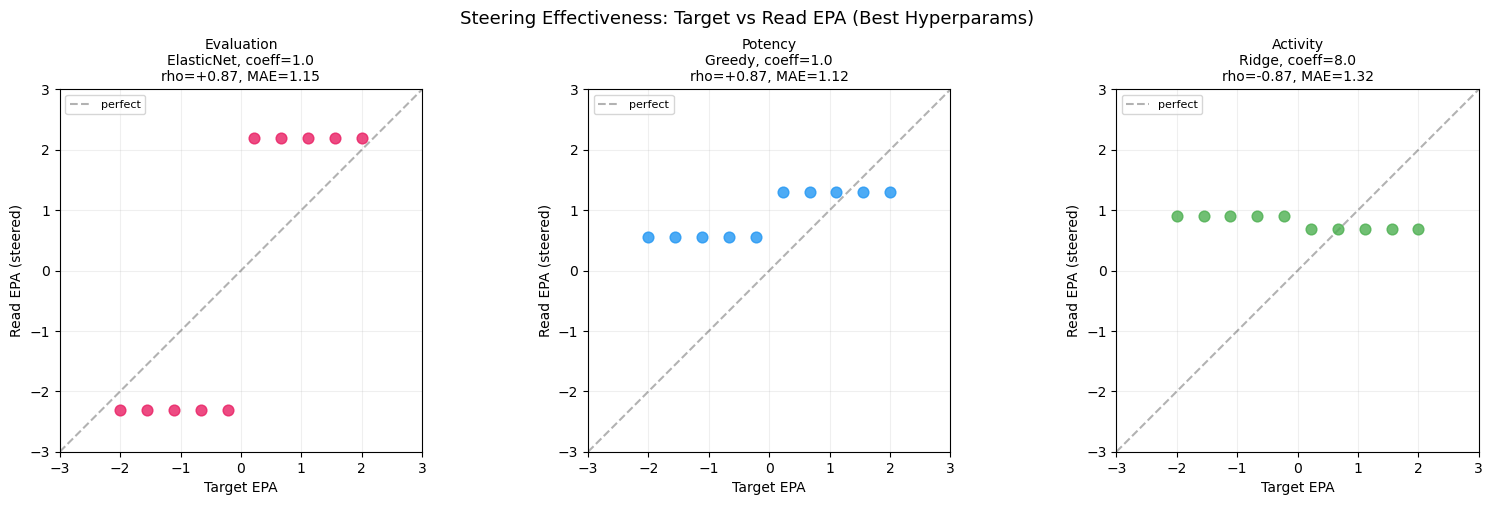

Saved steering_10_examples.png


In [23]:
# === Generate 10 Examples at Varying EPA Values Using Best Steering Hyperparams ===

# Use the overall best method+coeff per dimension
print("Setting up best steering configs...\n")
best_steering = {}
for dim in DIMENSIONS:
    method, coeff, mae = best_overall[dim]
    best_steering[dim] = {'method': method, 'coeff': coeff, 'mae': mae}
    print(f"  {dim}: method={method}, coeff={coeff:.1f}")

    # Rebuild steering_configs for best method
    method_data = ALL_METHODS[method][dim]
    cal = calibrations[method][dim]
    selected = method_data['selected']
    layers = sorted(selected.keys())
    signs = {}
    for layer in layers:
        reading_sign = 1.0 if phase1[dim][layer]['rho'] > 0 else -1.0
        signs[layer] = reading_sign
    steering_configs[dim] = {
        'layers': layers, 'signs': signs,
        'weights': {l: selected[l] for l in layers},
        'base_coeff': coeff,
        'calibration_slope': cal['slope'],
        'calibration_intercept': cal['intercept'],
        'lr': cal['lr'],
    }

# EPA target values spanning the range
EPA_TARGETS = np.linspace(-2.0, 2.0, 10)

prompt = format_for_reading("", neutral_context="Pretend you're a person making a statement in a conversation.")

# Generate for each dimension
for dim in DIMENSIONS:
    dim_key = DIM_KEY[dim]
    method = best_steering[dim]['method']
    coeff = best_steering[dim]['coeff']
    
    print(f"\n{'='*90}")
    print(f"GENERATING 10 EXAMPLES: {dim.upper()} (method={method}, coeff={coeff:.1f})")
    print(f"{'='*90}")
    
    override = {l: coeff for l in steering_configs[dim]['layers']}
    
    results_for_dim = []
    for i, target in enumerate(EPA_TARGETS):
        steered_text, _ = steer_and_generate(prompt, dim, target, coeff_override=override)
        steered_epa = read_and_calibrate(steered_text, method=method)
        
        read_e = steered_epa['evaluation']['calibrated']
        read_p = steered_epa['potency']['calibrated']
        read_a = steered_epa['activity']['calibrated']
        read_dim = steered_epa[dim]['calibrated']
        error = abs(read_dim - target)
        
        results_for_dim.append({
            'target': target, 'read': read_dim, 'error': error,
            'text': steered_text[:150], 'full_epa': (read_e, read_p, read_a),
        })
        
        print(f"\n  [{i+1}/10] Target {dim}={target:+.2f}")
        print(f"  Read EPA: E={read_e:+.2f}, P={read_p:+.2f}, A={read_a:+.2f}")
        print(f"  Read {dim}={read_dim:+.2f} (error={error:.2f})")
        print(f"  Text: {steered_text[:120]}{'...' if len(steered_text) > 120 else ''}")
    
    # Scatter: target vs read for this dimension
    targets = [r['target'] for r in results_for_dim]
    reads = [r['read'] for r in results_for_dim]
    rho_gen, _ = spearmanr(targets, reads) if len(set(targets)) > 1 else (0.0, 1.0)
    mae_gen = np.mean([r['error'] for r in results_for_dim])
    
    print(f"\n  Summary: Spearman rho={rho_gen:+.3f}, MAE={mae_gen:.3f}")

# --- Visualization: All 3 dims, target vs read ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
dim_colors = {'evaluation': '#E91E63', 'potency': '#2196F3', 'activity': '#4CAF50'}

for col, dim in enumerate(DIMENSIONS):
    method = best_steering[dim]['method']
    coeff = best_steering[dim]['coeff']
    override = {l: coeff for l in steering_configs[dim]['layers']}
    
    # Re-use results from above loop if possible, or regenerate
    targets_plot = list(EPA_TARGETS)
    reads_plot = []
    for target in targets_plot:
        steered_text, _ = steer_and_generate(prompt, dim, target, coeff_override=override)
        steered_epa = read_and_calibrate(steered_text, method=method)
        reads_plot.append(steered_epa[dim]['calibrated'])
    
    rho_p, _ = spearmanr(targets_plot, reads_plot)
    mae_p = np.mean([abs(t - r) for t, r in zip(targets_plot, reads_plot)])
    
    axes[col].scatter(targets_plot, reads_plot, c=dim_colors[dim], s=60, alpha=0.8, zorder=3)
    lims = [-3, 3]
    axes[col].plot(lims, lims, 'k--', alpha=0.3, label='perfect')
    axes[col].set_xlabel("Target EPA")
    axes[col].set_ylabel("Read EPA (steered)")
    axes[col].set_title(f"{dim.capitalize()}\n{method}, coeff={coeff:.1f}\n"
                        f"rho={rho_p:+.2f}, MAE={mae_p:.2f}", fontsize=10)
    axes[col].set_xlim(lims); axes[col].set_ylim(lims)
    axes[col].legend(fontsize=8)
    axes[col].grid(True, alpha=0.2)
    axes[col].set_aspect('equal')

plt.suptitle("Steering Effectiveness: Target vs Read EPA (Best Hyperparams)", fontsize=13)
plt.tight_layout()
plt.savefig("steering_10_examples.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved steering_10_examples.png")
